# 🧠 LSTM + Attention Worksheet: Urdu → English Machine Translation
### Applied Deep Learning | Seq2Seq: LSTM, Cross-Attention, Score Functions

---

**Instructions:**
- Every cell marked `# ✏️ YOUR CODE HERE` requires you to write code.
- Do **not** modify cells marked `# ✅ PROVIDED`.
- Run cells **in order** from top to bottom.
- Read the theory boxes carefully before writing code.

**What you will build today:**
```
Part A:  Urdu  →  [LSTM Encoder]  →  context vector  →  [LSTM Decoder]  →  English   (no attention)
Part B:  Urdu  →  [LSTM Encoder]  →  all hidden states  →  [Attention]  →  [Decoder]  →  English
Part C:  Implement 3 score functions: Dot · Scaled-Dot · Bahdanau
Part D:  Compare results & visualise attention heatmaps
```

**Framework:** PyTorch &nbsp;|&nbsp; **Model:** LSTM (upgraded from vanilla RNN)

---
## Section 0 — Setup

In [60]:
# ✅ PROVIDED
!pip install torch sacrebleu datasets

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import random, math, time, re
from collections import Counter
import sacrebleu
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
random.seed(42)
torch.manual_seed(42)

Device: cpu


You should consider upgrading via the 'F:\venv\Scripts\python.exe -m pip install --upgrade pip' command.


---
## Section 1 — Dataset

Same Urdu–English dataset as before (Helsinki-NLP). We use 3000 pairs for speed.

In [61]:
# ✅ PROVIDED — Data loading (same as original worksheet)
FALLBACK_PAIRS = [
    ("میں پاکستان سے ہوں", "I am from Pakistan"),
    ("وہ طالب علم ہے", "He is a student"),
    ("آج موسم اچھا ہے", "The weather is good today"),
    ("میں اردو بولتا ہوں", "I speak Urdu"),
    ("کتاب میز پر ہے", "The book is on the table"),
    ("وہ گھر جاتا ہے", "He goes home"),
    ("مجھے چائے پسند ہے", "I like tea"),
    ("آپ کا نام کیا ہے", "What is your name"),
    ("میں ٹھیک ہوں", "I am fine"),
    ("یہ میری کتاب ہے", "This is my book"),
] * 50

pairs = []
try:
    from datasets import load_dataset
    print("Loading from HuggingFace...")
    ds = load_dataset("Helsinki-NLP/opus-100", "en-ur", split="train[:3000]")
    for ex in ds:
        pairs.append((ex["translation"]["ur"], ex["translation"]["en"]))
    print(f"Loaded {len(pairs)} pairs.")
except Exception as e:
    print(f"HuggingFace failed ({e}), using fallback data.")
    pairs = FALLBACK_PAIRS

random.shuffle(pairs)
print(f"\nSample pair:")
print(f"  UR: {pairs[0][0][:60]}")
print(f"  EN: {pairs[0][1][:60]}")

Loading from HuggingFace...
Loaded 3000 pairs.

Sample pair:
  UR: اِن لوگوں کے سامنے (پچھلی قوموں کے) وہ حالات آ چکے ہیں جن می
  EN: They have certainly received the kind of news in which there


---
## Section 2 — Vocabulary & Tokenisation

In [62]:
# ✅ PROVIDED
PAD, SOS, EOS, UNK = 0, 1, 2, 3

def build_vocab(sentences, min_freq=2):
    counter = Counter()
    for s in sentences:
        counter.update(s.split())
    vocab = {"<PAD>": PAD, "<SOS>": SOS, "<EOS>": EOS, "<UNK>": UNK}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

def encode(sentence, vocab):
    return [vocab.get(w, UNK) for w in sentence.split()]

src_sents = [p[0] for p in pairs]
tgt_sents = [p[1] for p in pairs]
src_vocab = build_vocab(src_sents)
tgt_vocab = build_vocab(tgt_sents)
tgt_idx2word = {v: k for k, v in tgt_vocab.items()}

print(f"Source (Urdu) vocab size : {len(src_vocab)}")
print(f"Target (English) vocab size: {len(tgt_vocab)}")

Source (Urdu) vocab size : 3529
Target (English) vocab size: 4033


In [63]:
# ✅ PROVIDED — Dataset & DataLoader
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab, max_len=30):
        self.data = []
        for src, tgt in pairs:
            s = encode(src, src_vocab)
            t = encode(tgt, tgt_vocab)
            if 1 <= len(s) <= max_len and 1 <= len(t) <= max_len:
                self.data.append((
                    torch.tensor(s + [EOS], dtype=torch.long),
                    torch.tensor([SOS] + t + [EOS], dtype=torch.long)
                ))
    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

def collate_fn(batch):
    srcs, tgts = zip(*batch)
    return (pad_sequence(srcs, batch_first=True, padding_value=PAD),
            pad_sequence(tgts, batch_first=True, padding_value=PAD))

split = int(0.9 * len(pairs))
train_ds = TranslationDataset(pairs[:split], src_vocab, tgt_vocab)
val_ds   = TranslationDataset(pairs[split:], src_vocab, tgt_vocab)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, collate_fn=collate_fn)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 26 | Val batches: 3


---
## Section 3 — LSTM Encoder (upgrade from vanilla RNN)

> **Theory recap:** Vanilla RNN suffers from vanishing gradients for long Urdu sentences.
> LSTM adds **cell state** `c` and three gates (input, forget, output):
>
> ```
> fₜ = σ(Wf [hₜ₋₁, xₜ] + bf)        ← forget gate
> iₜ = σ(Wi [hₜ₋₁, xₜ] + bi)        ← input gate
> c̃ₜ = tanh(Wc [hₜ₋₁, xₜ] + bc)    ← candidate cell
> cₜ = fₜ ⊙ cₜ₋₁ + iₜ ⊙ c̃ₜ         ← updated cell state
> oₜ = σ(Wo [hₜ₋₁, xₜ] + bo)        ← output gate
> hₜ = oₜ ⊙ tanh(cₜ)                ← hidden state
> ```
>
> Key difference from RNN: **LSTM returns BOTH (h, c) as its state tuple.**
> The encoder also returns ALL hidden states `h₁..hT` — needed for attention.

In [64]:
class LSTMEncoder(nn.Module):
    """
    LSTM Encoder: reads Urdu tokens, returns all hidden states + final (h, c).

    Unlike vanilla RNN, LSTM state is a TUPLE (h, c).
    We return ALL encoder hidden states because the attention decoder needs them.

    Args:
        vocab_size : size of source (Urdu) vocabulary
        embed_dim  : embedding dimension
        hidden_dim : LSTM hidden dimension
        dropout    : dropout probability

    Returns:
        enc_outputs : (batch, src_len, hidden_dim)  ← ALL hidden states
        hidden      : tuple (h, c), each (1, batch, hidden_dim)
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)

        

    def forward(self, src):
        # ✏️ YOUR CODE HERE
        embedded = self.dropout(self.embedding(src))  # (batch, src_len, embed_dim)
        enc_outputs, (h, c) = self.lstm(embedded)     # enc_outputs (batch, src_len, hidden_dim)
        return enc_outputs, (h, c)
        # 1. embedded = dropout(embedding(src))        → (batch, src_len, embed_dim)
        # 2. enc_outputs, (h, c) = lstm(embedded)     → outputs (batch, src_len, hidden_dim)
        # 3. return enc_outputs, (h, c)
        

---
## Section 4 — Part A: LSTM Decoder WITHOUT Attention

> **Theory:** Classical decoder — initialised with encoder's final **(h, c)**.
> The context is fixed: only the last hidden state is used.
> This is the **bottleneck** we discussed in lectures.
>
> ```
> sₜ, (h,c) = LSTM([yₜ₋₁; c],  (h,c))
> P(yₜ)     = softmax(W sₜ)
> ```
> Note: for the baseline, we concatenate the fixed context vector `c` with
> the input embedding at each step (a common improvement over pure RNN).

In [65]:
class LSTMDecoderNoAttn(nn.Module):
    """
    LSTM Decoder WITHOUT attention.
    Uses only the encoder's final hidden state as context (fixed throughout decoding).

    At each step the input to LSTM is: [embedding(yₜ₋₁) ; fixed_context]
    fixed_context = encoder final hidden state h (squeezed to (batch, hidden_dim))
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout=0.3):
        super().__init__()
        # ✏️ YOUR CODE HERE
        self.embedding =nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        self.lstm = nn.LSTM(embed_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)
        # 1. nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        # 2. nn.LSTM(embed_dim + hidden_dim, hidden_dim, batch_first=True)
        #    ↑ input is concat of embedding + context
        # 3. nn.Linear(hidden_dim, vocab_size)   ← output projection
        # 4. nn.Dropout(dropout)
       

    def forward(self, tgt, enc_final_hidden):
        """
        tgt              : (batch, tgt_len)  — teacher-forced target tokens
        enc_final_hidden : tuple (h, c), each (1, batch, hidden_dim)

        Returns:
            logits : (batch, tgt_len, vocab_size)
        """
        # ✏️ YOUR CODE HERE
        fixed_context = enc_final_hidden[0].squeeze(0)  # (batch, hidden_dim)
        ctx_expanded = fixed_context.unsqueeze(1).expand(-1, tgt.size(1), -1)  # (batch, tgt_len, hidden_dim)
        embedded = self.dropout(self.embedding(tgt))  # (batch, tgt_len, embed_dim)
        lstm_input = torch.cat([embedded, ctx_expanded], dim=-1)  # (batch, tgt_len, embed_dim + hidden_dim)
        output, _ = self.lstm(lstm_input, enc_final_hidden)  # output (batch, tgt_len, hidden_dim)
        logits = self.fc(self.dropout(output))  # (batch, tgt_len, vocab_size)
        return logits
        # Hint:
        # 1. fixed_context = enc_final_hidden[0].squeeze(0)  → (batch, hidden_dim)
        #    Expand it to match tgt length:
        #    ctx_expanded = fixed_context.unsqueeze(1).expand(-1, tgt.size(1), -1)
        # 2. embedded = dropout(embedding(tgt))              → (batch, tgt_len, embed_dim)
        # 3. lstm_input = torch.cat([embedded, ctx_expanded], dim=-1)
        # 4. output, _ = lstm(lstm_input, enc_final_hidden)
        # 5. logits = fc(dropout(output))                    → (batch, tgt_len, vocab_size)
        # 6. return logits

---
## Section 5 — Attention Score Functions

> ### Three score functions you must implement:
>
> **1. Dot-product attention** (Luong, simple):
> ```
> score(hᵢ, sₜ) = hᵢᵀ · sₜ
> ```
> Requires encoder and decoder hidden dims to be equal.
>
> **2. Scaled dot-product** (Vaswani / Transformer):
> ```
> score(hᵢ, sₜ) = (hᵢᵀ · sₜ) / √dₖ
> ```
> Dividing by √dₖ prevents softmax saturation for large hidden dims.
>
> **3. Bahdanau (additive)**:
> ```
> score(hᵢ, sₜ) = vᵀ tanh(W₁hᵢ + W₂sₜ)
> ```
> Uses learned parameters W₁, W₂, v — more expressive but more parameters.
>
> **After scoring → softmax → weighted sum:**
> ```
> αᵢ = softmax(scores)ᵢ
> cₜ = Σᵢ αᵢ hᵢ            ← dynamic context vector
> ```

In [66]:
class DotAttention(nn.Module):
    """
    Dot-product cross-attention.
    score(hᵢ, sₜ) = hᵢᵀ · sₜ

    Args:
        enc_outputs : (batch, src_len, hidden_dim)
        decoder_h   : (batch, 1, hidden_dim)  ← current decoder state

    Returns:
        context     : (batch, 1, hidden_dim)  ← weighted sum of encoder states
        attn_weights: (batch, 1, src_len)     ← attention distribution
    """
    def forward(self, enc_outputs, decoder_h):
        # ✏️ YOUR CODE HERE
        # Hint:
        # scores = torch.bmm(decoder_h, enc_outputs.transpose(1,2))  → (batch,1,src_len)
        # attn_weights = F.softmax(scores, dim=-1)
        # context = torch.bmm(attn_weights, enc_outputs)              → (batch,1,hidden_dim)
        # return context, attn_weights
        scores = torch.bmm(decoder_h, enc_outputs.transpose(1, 2))  # (batch, 1, src_len)
        attn_weights = F.softmax(scores, dim=-1)                     # (batch, 1, src_len)
        context = torch.bmm(attn_weights, enc_outputs)              # (batch, 1, hidden_dim)
        return context, attn_weights    


class ScaledDotAttention(nn.Module):
    """
    Scaled dot-product attention.
    score(hᵢ, sₜ) = (hᵢᵀ · sₜ) / √dₖ
    """
    def forward(self, enc_outputs, decoder_h):
        # ✏️ YOUR CODE HERE
        # Hint: same as DotAttention but divide scores by math.sqrt(enc_outputs.size(-1))
        # before applying softmax
        scores = torch.bmm(decoder_h, enc_outputs.transpose(1, 2))  # (batch, 1, src_len)
        scores = scores / math.sqrt(enc_outputs.size(-1))          # scale by sqrt(d_k)
        attn_weights = F.softmax(scores, dim=-1)                     # (batch, 1, src_len)
        context = torch.bmm(attn_weights, enc_outputs)              # (batch, 1, hidden_dim)
        return context, attn_weights    
        


class BahdanauAttention(nn.Module):
    """
    Bahdanau (additive) attention.
    score(hᵢ, sₜ) = vᵀ tanh(W₁hᵢ + W₂sₜ)

    Parameters to create in __init__:
        W1 : nn.Linear(hidden_dim, hidden_dim, bias=False)
        W2 : nn.Linear(hidden_dim, hidden_dim, bias=False)
        v  : nn.Linear(hidden_dim, 1, bias=False)
    """
    def __init__(self, hidden_dim):
        super().__init__()
        # ✏️ YOUR CODE HERE
        self.W1 = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W2 = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.v = nn.Linear(hidden_dim, 1, bias=False)   
        # Create W1, W2, v as described above
       

    def forward(self, enc_outputs, decoder_h):
        """
        enc_outputs : (batch, src_len, hidden_dim)
        decoder_h   : (batch, 1, hidden_dim)

        Returns context (batch, 1, hidden_dim) and attn_weights (batch, 1, src_len)
        """
        # ✏️ YOUR CODE HERE
        energy = self.v(torch.tanh(self.W1(enc_outputs) + self.W2(decoder_h)))  # (batch, src_len, 1)
        scores = energy.transpose(1, 2)        # (batch, 1, src_len)
        attn_weights = F.softmax(scores, dim=-1)  # (batch, 1, src_len)
        context = torch.bmm(attn_weights, enc_outputs)              # (batch, 1, hidden_dim)
        return context, attn_weights
        # Hint:
        # energy = self.v(torch.tanh(self.W1(enc_outputs) + self.W2(decoder_h)))
        # energy → (batch, src_len, 1)
        # scores = energy.transpose(1, 2)        → (batch, 1, src_len)
        # attn_weights = F.softmax(scores, dim=-1)
        # context = torch.bmm(attn_weights, enc_outputs)
        # return context, attn_weights

---
## Section 6 — Part B: LSTM Decoder WITH Attention

> At each decoder step t:
> 1. Compute scores between decoder state `sₜ` and **all** encoder states
> 2. Softmax → attention weights `αᵢ`
> 3. Dynamic context `cₜ = Σ αᵢ hᵢ`
> 4. LSTM input = `[embedding(yₜ₋₁) ; cₜ]`
> 5. Output logit from `[sₜ ; cₜ]` concatenation

In [67]:
class LSTMDecoderWithAttn(nn.Module):
    """
    LSTM Decoder WITH cross-attention.
    Accepts a score_fn (one of DotAttention, ScaledDotAttention, BahdanauAttention).

    At each step:
      - Query  = current decoder hidden state (sₜ)
      - Keys   = all encoder hidden states
      - Values = all encoder hidden states
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, score_fn, dropout=0.3):
        super().__init__()
        self.score_fn = score_fn
        # ✏️ YOUR CODE HERE
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        self.lstm = nn.LSTM(embed_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2, vocab_size)   # concat [sₜ, cₜ] before projection
        self.dropout = nn.Dropout(dropout)
        # 1. nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        # 2. nn.LSTM(embed_dim + hidden_dim, hidden_dim, batch_first=True)
        #    ↑ input is concat of embedding + context from attention
        # 3. nn.Linear(hidden_dim * 2, vocab_size)   ← concat [sₜ, cₜ] before projection
        # 4. nn.Dropout(dropout)

    def forward(self, tgt, enc_outputs, enc_hidden):
        """
        tgt         : (batch, tgt_len)  — teacher-forced tokens
        enc_outputs : (batch, src_len, hidden_dim)
        enc_hidden  : tuple (h, c)

        Returns:
            logits       : (batch, tgt_len, vocab_size)
            all_attn     : (batch, tgt_len, src_len)  ← for visualisation
        """
        # ✏️ YOUR CODE HERE
        hidden = enc_hidden
        all_logits, all_attn = [], []
        # Process token by token (loop over tgt_len) so attention is per-step:
        for t in range(tgt.size(1)):
            token = tgt[:, t].unsqueeze(1)           # (batch, 1)
            emb   = self.dropout(self.embedding(token))        # (batch, 1, embed_dim)
            q     = hidden[0].permute(1,0,2)         # (batch, 1, hidden_dim)  ← query
            ctx, attn_w = self.score_fn(enc_outputs, q)   # ctx (batch,1,hidden_dim)
            lstm_in = torch.cat([emb, ctx], dim=-1)  # (batch, 1, embed+hidden)
            out, hidden = self.lstm(lstm_in, hidden)      # out (batch,1,hidden_dim)
            out_ctx = torch.cat([out, ctx], dim=-1)  # (batch,1,hidden*2)
            logit   = self.fc(self.dropout(out_ctx))           # (batch,1,vocab_size)
            all_logits.append(logit)
            all_attn.append(attn_w)
        # hidden = enc_hidden
        # all_logits, all_attn = [], []
        # for t in range(tgt.size(1)):
        #     token = tgt[:, t].unsqueeze(1)           → (batch, 1)
        #     emb   = dropout(embedding(token))        → (batch, 1, embed_dim)
        #     q     = hidden[0].permute(1,0,2)         → (batch, 1, hidden_dim)  ← query
        #     ctx, attn_w = score_fn(enc_outputs, q)   → ctx (batch,1,hidden_dim)
        #     lstm_in = torch.cat([emb, ctx], dim=-1)  → (batch, 1, embed+hidden)
        #     out, hidden = lstm(lstm_in, hidden)      → out (batch,1,hidden_dim)
        #     out_ctx = torch.cat([out, ctx], dim=-1)  → (batch,1,hidden*2)
        #     logit   = fc(dropout(out_ctx))           → (batch,1,vocab_size)
        #     all_logits.append(logit)
        #     all_attn.append(attn_w)
        #
        # logits   = torch.cat(all_logits, dim=1)      → (batch, tgt_len, vocab_size)
        # all_attn = torch.cat(all_attn,   dim=1)      → (batch, tgt_len, src_len)
        # return logits, all_attn
        logits   = torch.cat(all_logits, dim=1)      # (batch, tgt_len, vocab_size)
        all_attn = torch.cat(all_attn,   dim=1)      # (batch, tgt_len, src_len)
        return logits, all_attn

---
## Section 7 — Training Loop (shared for both models)

> The training loop is the same for both models.
> The only difference is how the decoder forward() is called.
> We use **teacher forcing** — feed ground truth tokens as decoder input.

In [68]:
# ✅ PROVIDED — Training & evaluation utilities
def train_epoch(encoder, decoder, loader, enc_opt, dec_opt, criterion, use_attn=False):
    encoder.train(); decoder.train()
    total_loss = 0
    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        enc_opt.zero_grad(); dec_opt.zero_grad()
        enc_out, enc_hidden = encoder(src)
        dec_input  = tgt[:, :-1]   # SOS ... last-1
        dec_target = tgt[:, 1:]    # first+1 ... EOS
        if use_attn:
            logits, _ = decoder(dec_input, enc_out, enc_hidden)
        else:
            logits = decoder(dec_input, enc_hidden)
        loss = criterion(logits.reshape(-1, logits.size(-1)), dec_target.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(encoder.parameters()) + list(decoder.parameters()), 1.0)
        enc_opt.step(); dec_opt.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def eval_epoch(encoder, decoder, loader, criterion, use_attn=False):
    encoder.eval(); decoder.eval()
    total_loss = 0
    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        enc_out, enc_hidden = encoder(src)
        dec_input  = tgt[:, :-1]
        dec_target = tgt[:, 1:]
        if use_attn:
            logits, _ = decoder(dec_input, enc_out, enc_hidden)
        else:
            logits = decoder(dec_input, enc_hidden)
        loss = criterion(logits.reshape(-1, logits.size(-1)), dec_target.reshape(-1))
        total_loss += loss.item()
    return total_loss / len(loader)


def train_model(encoder, decoder, use_attn=False, n_epochs=10, lr=1e-3):
    criterion = nn.CrossEntropyLoss(ignore_index=PAD)
    enc_opt = optim.Adam(encoder.parameters(), lr=lr)
    dec_opt = optim.Adam(decoder.parameters(), lr=lr)
    train_losses, val_losses = [], []
    for epoch in range(1, n_epochs + 1):
        tl = train_epoch(encoder, decoder, train_loader, enc_opt, dec_opt, criterion, use_attn)
        vl = eval_epoch (encoder, decoder, val_loader,   criterion, use_attn)
        train_losses.append(tl); val_losses.append(vl)
        print(f"Epoch {epoch:2d} | Train Loss: {tl:.4f} | Val Loss: {vl:.4f} | PPL: {math.exp(vl):.2f}")
    return train_losses, val_losses

print("Utilities ready.")

Utilities ready.


---
## Section 8 — Hyperparameters & Model Instantiation

In [69]:
# ✅ PROVIDED
EMBED_DIM  = 128
HIDDEN_DIM = 256
DROPOUT    = 0.3
N_EPOCHS   = 20

# ---- Model A: No Attention ----
enc_base = LSTMEncoder(len(src_vocab), EMBED_DIM, HIDDEN_DIM, DROPOUT).to(DEVICE)
dec_base = LSTMDecoderNoAttn(len(tgt_vocab), EMBED_DIM, HIDDEN_DIM, DROPOUT).to(DEVICE)

# ---- Models B1/B2/B3: With Attention (3 score functions) ----
enc_dot  = LSTMEncoder(len(src_vocab), EMBED_DIM, HIDDEN_DIM, DROPOUT).to(DEVICE)
dec_dot  = LSTMDecoderWithAttn(len(tgt_vocab), EMBED_DIM, HIDDEN_DIM, DotAttention(), DROPOUT).to(DEVICE)

enc_scaled = LSTMEncoder(len(src_vocab), EMBED_DIM, HIDDEN_DIM, DROPOUT).to(DEVICE)
dec_scaled = LSTMDecoderWithAttn(len(tgt_vocab), EMBED_DIM, HIDDEN_DIM, ScaledDotAttention(), DROPOUT).to(DEVICE)

enc_bah  = LSTMEncoder(len(src_vocab), EMBED_DIM, HIDDEN_DIM, DROPOUT).to(DEVICE)
dec_bah  = LSTMDecoderWithAttn(len(tgt_vocab), EMBED_DIM, HIDDEN_DIM, BahdanauAttention(HIDDEN_DIM), DROPOUT).to(DEVICE)

def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"Encoder params      : {count_params(enc_base):,}")
print(f"Decoder (no attn)   : {count_params(dec_base):,}")
print(f"Decoder (Bahdanau)  : {count_params(dec_bah):,}")

Encoder params      : 846,976
Decoder (no attn)   : 2,210,113
Decoder (Bahdanau)  : 3,373,889


---
## Section 9 — Train All Four Models

> ⏱️ This will take a few minutes. Watch the loss curves — you should see
> the attention models converge to lower perplexity than the baseline.
>
> **Perplexity (PPL)** = e^(val_loss). Lower is better.
> A PPL of 1 = perfect prediction. Typical values here: 20–80.

In [70]:
print("=" * 55)
print("MODEL A: LSTM Encoder-Decoder (NO attention)")
print("=" * 55)
losses_base = train_model(enc_base, dec_base, use_attn=False, n_epochs=N_EPOCHS)

MODEL A: LSTM Encoder-Decoder (NO attention)
Epoch  1 | Train Loss: 6.8102 | Val Loss: 5.8543 | PPL: 348.73
Epoch  2 | Train Loss: 5.6749 | Val Loss: 5.7146 | PPL: 303.27
Epoch  3 | Train Loss: 5.5193 | Val Loss: 5.6310 | PPL: 278.95
Epoch  4 | Train Loss: 5.4015 | Val Loss: 5.5489 | PPL: 256.95
Epoch  5 | Train Loss: 5.2970 | Val Loss: 5.4771 | PPL: 239.14
Epoch  6 | Train Loss: 5.1770 | Val Loss: 5.4054 | PPL: 222.61
Epoch  7 | Train Loss: 5.0677 | Val Loss: 5.3499 | PPL: 210.60
Epoch  8 | Train Loss: 4.9728 | Val Loss: 5.2816 | PPL: 196.68
Epoch  9 | Train Loss: 4.8789 | Val Loss: 5.2389 | PPL: 188.47
Epoch 10 | Train Loss: 4.7983 | Val Loss: 5.2034 | PPL: 181.89
Epoch 11 | Train Loss: 4.7256 | Val Loss: 5.1658 | PPL: 175.18
Epoch 12 | Train Loss: 4.6465 | Val Loss: 5.1440 | PPL: 171.40
Epoch 13 | Train Loss: 4.5825 | Val Loss: 5.1113 | PPL: 165.89
Epoch 14 | Train Loss: 4.5131 | Val Loss: 5.0883 | PPL: 162.11
Epoch 15 | Train Loss: 4.4508 | Val Loss: 5.0719 | PPL: 159.48
Epoch 16 |

In [71]:
print("=" * 55)
print("MODEL B1: LSTM + Dot-Product Attention")
print("=" * 55)
losses_dot = train_model(enc_dot, dec_dot, use_attn=True, n_epochs=N_EPOCHS)

MODEL B1: LSTM + Dot-Product Attention
Epoch  1 | Train Loss: 6.7689 | Val Loss: 5.8379 | PPL: 343.05
Epoch  2 | Train Loss: 5.6211 | Val Loss: 5.6744 | PPL: 291.31
Epoch  3 | Train Loss: 5.4362 | Val Loss: 5.5775 | PPL: 264.40
Epoch  4 | Train Loss: 5.2857 | Val Loss: 5.4902 | PPL: 242.30
Epoch  5 | Train Loss: 5.1375 | Val Loss: 5.3939 | PPL: 220.07
Epoch  6 | Train Loss: 4.9991 | Val Loss: 5.3270 | PPL: 205.83
Epoch  7 | Train Loss: 4.8492 | Val Loss: 5.2577 | PPL: 192.04
Epoch  8 | Train Loss: 4.7217 | Val Loss: 5.2151 | PPL: 184.04
Epoch  9 | Train Loss: 4.5946 | Val Loss: 5.1582 | PPL: 173.86
Epoch 10 | Train Loss: 4.4688 | Val Loss: 5.1197 | PPL: 167.29
Epoch 11 | Train Loss: 4.3467 | Val Loss: 5.0923 | PPL: 162.76
Epoch 12 | Train Loss: 4.2345 | Val Loss: 5.0577 | PPL: 157.23
Epoch 13 | Train Loss: 4.1193 | Val Loss: 5.0333 | PPL: 153.44
Epoch 14 | Train Loss: 4.0127 | Val Loss: 5.0002 | PPL: 148.44
Epoch 15 | Train Loss: 3.8947 | Val Loss: 4.9959 | PPL: 147.81
Epoch 16 | Train

In [72]:
print("=" * 55)
print("MODEL B2: LSTM + Scaled Dot-Product Attention")
print("=" * 55)
losses_scaled = train_model(enc_scaled, dec_scaled, use_attn=True, n_epochs=N_EPOCHS)

MODEL B2: LSTM + Scaled Dot-Product Attention
Epoch  1 | Train Loss: 6.7417 | Val Loss: 5.8036 | PPL: 331.51
Epoch  2 | Train Loss: 5.6066 | Val Loss: 5.6824 | PPL: 293.64
Epoch  3 | Train Loss: 5.4344 | Val Loss: 5.5825 | PPL: 265.74
Epoch  4 | Train Loss: 5.3004 | Val Loss: 5.5071 | PPL: 246.44
Epoch  5 | Train Loss: 5.1642 | Val Loss: 5.4135 | PPL: 224.43
Epoch  6 | Train Loss: 5.0233 | Val Loss: 5.3276 | PPL: 205.95
Epoch  7 | Train Loss: 4.8703 | Val Loss: 5.2460 | PPL: 189.80
Epoch  8 | Train Loss: 4.7199 | Val Loss: 5.1800 | PPL: 177.68
Epoch  9 | Train Loss: 4.5785 | Val Loss: 5.1181 | PPL: 167.03
Epoch 10 | Train Loss: 4.4424 | Val Loss: 5.0738 | PPL: 159.79
Epoch 11 | Train Loss: 4.3020 | Val Loss: 5.0339 | PPL: 153.53
Epoch 12 | Train Loss: 4.1699 | Val Loss: 5.0013 | PPL: 148.61
Epoch 13 | Train Loss: 4.0224 | Val Loss: 4.9722 | PPL: 144.34
Epoch 14 | Train Loss: 3.8840 | Val Loss: 4.9444 | PPL: 140.38
Epoch 15 | Train Loss: 3.7549 | Val Loss: 4.9452 | PPL: 140.49
Epoch 16 

In [73]:
print("=" * 55)
print("MODEL B3: LSTM + Bahdanau (Additive) Attention")
print("=" * 55)
losses_bah = train_model(enc_bah, dec_bah, use_attn=True, n_epochs=N_EPOCHS)

MODEL B3: LSTM + Bahdanau (Additive) Attention
Epoch  1 | Train Loss: 6.7106 | Val Loss: 5.7863 | PPL: 325.80
Epoch  2 | Train Loss: 5.5938 | Val Loss: 5.6619 | PPL: 287.69
Epoch  3 | Train Loss: 5.4160 | Val Loss: 5.5699 | PPL: 262.42
Epoch  4 | Train Loss: 5.2771 | Val Loss: 5.4797 | PPL: 239.78
Epoch  5 | Train Loss: 5.1403 | Val Loss: 5.3924 | PPL: 219.73
Epoch  6 | Train Loss: 5.0062 | Val Loss: 5.3140 | PPL: 203.17
Epoch  7 | Train Loss: 4.8675 | Val Loss: 5.2484 | PPL: 190.26
Epoch  8 | Train Loss: 4.7418 | Val Loss: 5.1893 | PPL: 179.34
Epoch  9 | Train Loss: 4.6139 | Val Loss: 5.1350 | PPL: 169.86
Epoch 10 | Train Loss: 4.4836 | Val Loss: 5.0766 | PPL: 160.22
Epoch 11 | Train Loss: 4.3514 | Val Loss: 5.0402 | PPL: 154.49
Epoch 12 | Train Loss: 4.2205 | Val Loss: 4.9997 | PPL: 148.37
Epoch 13 | Train Loss: 4.0896 | Val Loss: 4.9733 | PPL: 144.50
Epoch 14 | Train Loss: 3.9613 | Val Loss: 4.9362 | PPL: 139.25
Epoch 15 | Train Loss: 3.8025 | Val Loss: 4.9297 | PPL: 138.34
Epoch 16

---
## Section 10 — Compare Training Curves

> Plot all four models' **validation loss** on one graph.
> Which converges fastest? Which reaches the lowest loss?
> Write your observations in the markdown cell below.

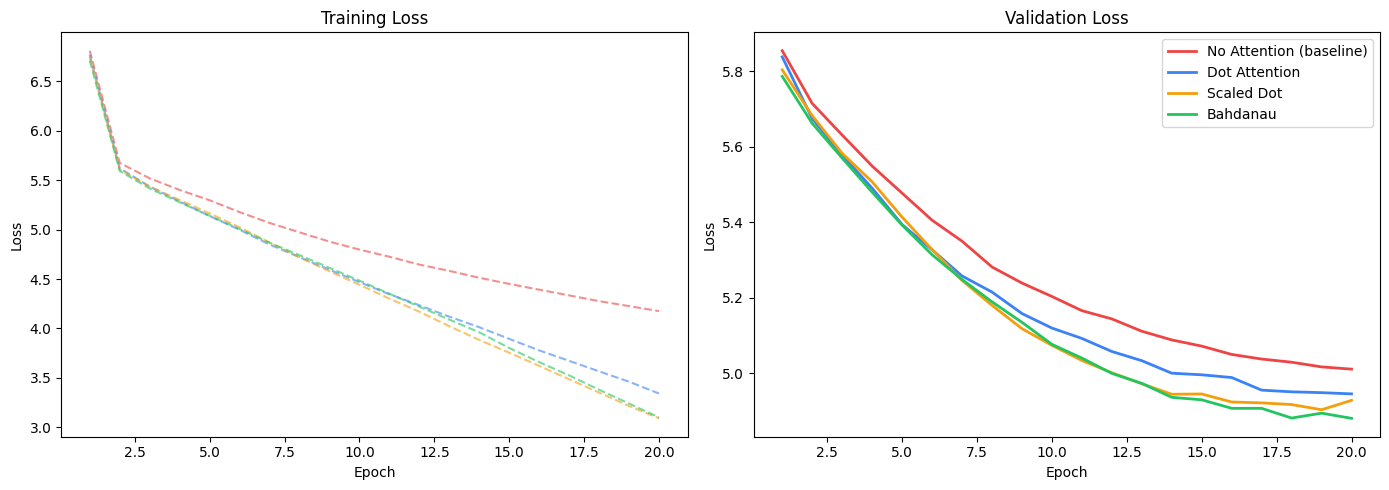


Final Val Loss Summary:
  No Attention (baseline)            : 5.0109  (PPL=150.04)
  Dot Attention                      : 4.9454  (PPL=140.53)
  Scaled Dot                         : 4.9282  (PPL=138.14)
  Bahdanau                           : 4.8806  (PPL=131.71)


In [74]:
# ✅ PROVIDED — Loss curve comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, N_EPOCHS + 1)
labels  = ['No Attention (baseline)', 'Dot Attention', 'Scaled Dot', 'Bahdanau']
colors  = ['#ef4444', '#3b82f6', '#f59e0b', '#22c55e']
all_losses = [losses_base, losses_dot, losses_scaled, losses_bah]

for (tl, vl), lbl, col in zip(all_losses, labels, colors):
    axes[0].plot(epochs, tl, color=col, linestyle='--', alpha=0.6)
    axes[1].plot(epochs, vl, color=col, label=lbl, linewidth=2)

axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[1].set_title('Validation Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend()
plt.tight_layout()
plt.savefig('loss_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nFinal Val Loss Summary:")
for lbl, (_, vl) in zip(labels, all_losses):
    print(f"  {lbl:35s}: {vl[-1]:.4f}  (PPL={math.exp(vl[-1]):.2f})")

### ✏️ Student Observation — Loss Curves

*Fill in your answers:*

1. Which model has the highest final validation loss? Why?
2. Is the difference between Dot and Scaled-Dot significant? Explain.
3. Does Bahdanau attention converge faster or slower? Why might that be?
4. What does lower PPL tell you about the model's uncertainty?

**Your answers here:**

```
1. 
2. 
3. 
4. 
```

---
## Section 11 — Inference & Translation

In [75]:
# ✅ PROVIDED — Greedy decode
@torch.no_grad()
def translate(encoder, decoder, sentence, use_attn=False, max_len=30):
    encoder.eval(); decoder.eval()
    tokens = torch.tensor(encode(sentence, src_vocab) + [EOS]).unsqueeze(0).to(DEVICE)
    enc_out, enc_hidden = encoder(tokens)
    dec_token = torch.tensor([[SOS]]).to(DEVICE)
    result, attn_record = [], []
    hidden = enc_hidden
    for _ in range(max_len):
        if use_attn:
            q = hidden[0].permute(1, 0, 2)
            ctx, attn_w = decoder.score_fn(enc_out, q)
            emb = decoder.dropout(decoder.embedding(dec_token))
            lstm_in = torch.cat([emb, ctx], dim=-1)
            out, hidden = decoder.lstm(lstm_in, hidden)
            out_ctx = torch.cat([out, ctx], dim=-1)
            logit = decoder.fc(out_ctx)
            attn_record.append(attn_w.squeeze().cpu().numpy())
        else:
            fixed_ctx = enc_hidden[0].squeeze(0).unsqueeze(1)
            emb = decoder.dropout(decoder.embedding(dec_token))
            lstm_in = torch.cat([emb, fixed_ctx], dim=-1)
            out, hidden = decoder.lstm(lstm_in, hidden)
            logit = decoder.fc(decoder.dropout(out))
        pred = logit.argmax(-1).item()
        if pred == EOS: break
        result.append(tgt_idx2word.get(pred, '<UNK>'))
        dec_token = torch.tensor([[pred]]).to(DEVICE)
    return ' '.join(result), attn_record

print("Translate function ready.")

Translate function ready.


In [76]:
# ✅ PROVIDED — Translation comparison
test_sentences = [p[0] for p in pairs[split:split+5]]
gold_sentences = [p[1] for p in pairs[split:split+5]]

print(f"{'Urdu Input':<35} {'Gold':<25} {'No Attn':<25} {'Bahdanau':<25}")
print("-" * 115)
for src_s, gold in zip(test_sentences, gold_sentences):
    pred_base, _ = translate(enc_base, dec_base, src_s, use_attn=False)
    pred_bah,  _ = translate(enc_bah,  dec_bah,  src_s, use_attn=True)
    print(f"{src_s[:33]:<35} {gold[:23]:<25} {pred_base[:23]:<25} {pred_bah[:23]:<25}")

Urdu Input                          Gold                      No Attn                   Bahdanau                 
-------------------------------------------------------------------------------------------------------------------
اور اگر وہ ایمان لاتے اور پرہیز گ   Had they come to believ   And We have sent to the   And if they had believe  
اور (اس کے بعد) ایک دوسرے کی طرف    and approach each other   And We have sent to the   And the <UNK> of the <U  
اور ان میں کیا بات ہے کہ ان کو ال   And why should Allah no   And We have sent you to   And when they had not <  
اور جو لوگ ہدایت یافتہ ہیں اللہ ن   While as for those who    And We have sent to the   And those who believe a  
میں آپ کی بات سے متفق ہوں جو بھی    You know, you're right,   And We have sent to the   <UNK> <UNK> <UNK> <UNK>  


---
## Section 12 — Visualise Attention Heatmap

> **Key insight:** Each row of the attention matrix = one decoder step.
> Each column = one encoder (Urdu) token.
> A bright cell means "when generating this English word, the model
> looked at this Urdu word most."
> This makes the model **interpretable**.

C:\Users\Mani\AppData\Local\Temp\ipykernel_17464\3419337391.py:23: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Mani\AppData\Local\Temp\ipykernel_17464\3419337391.py:23: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
C:\Users\Mani\AppData\Local\Temp\ipykernel_17464\3419337391.py:23: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Mani\AppData\Local\Temp\ipykernel_17464\3419337391.py:24: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.savefig(f'attn_{title.replace(" ","_").lower()}.png', dpi=120, bbox_inches='tight')
C:\Users\Mani\AppData\Local\Temp\ipykernel_17464\3419337391.py:24: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig(f'attn_{title.replace(" ","_").lower()}.png', dpi=120, bbox_inches='tight')
C:\Users\Mani\AppData\L

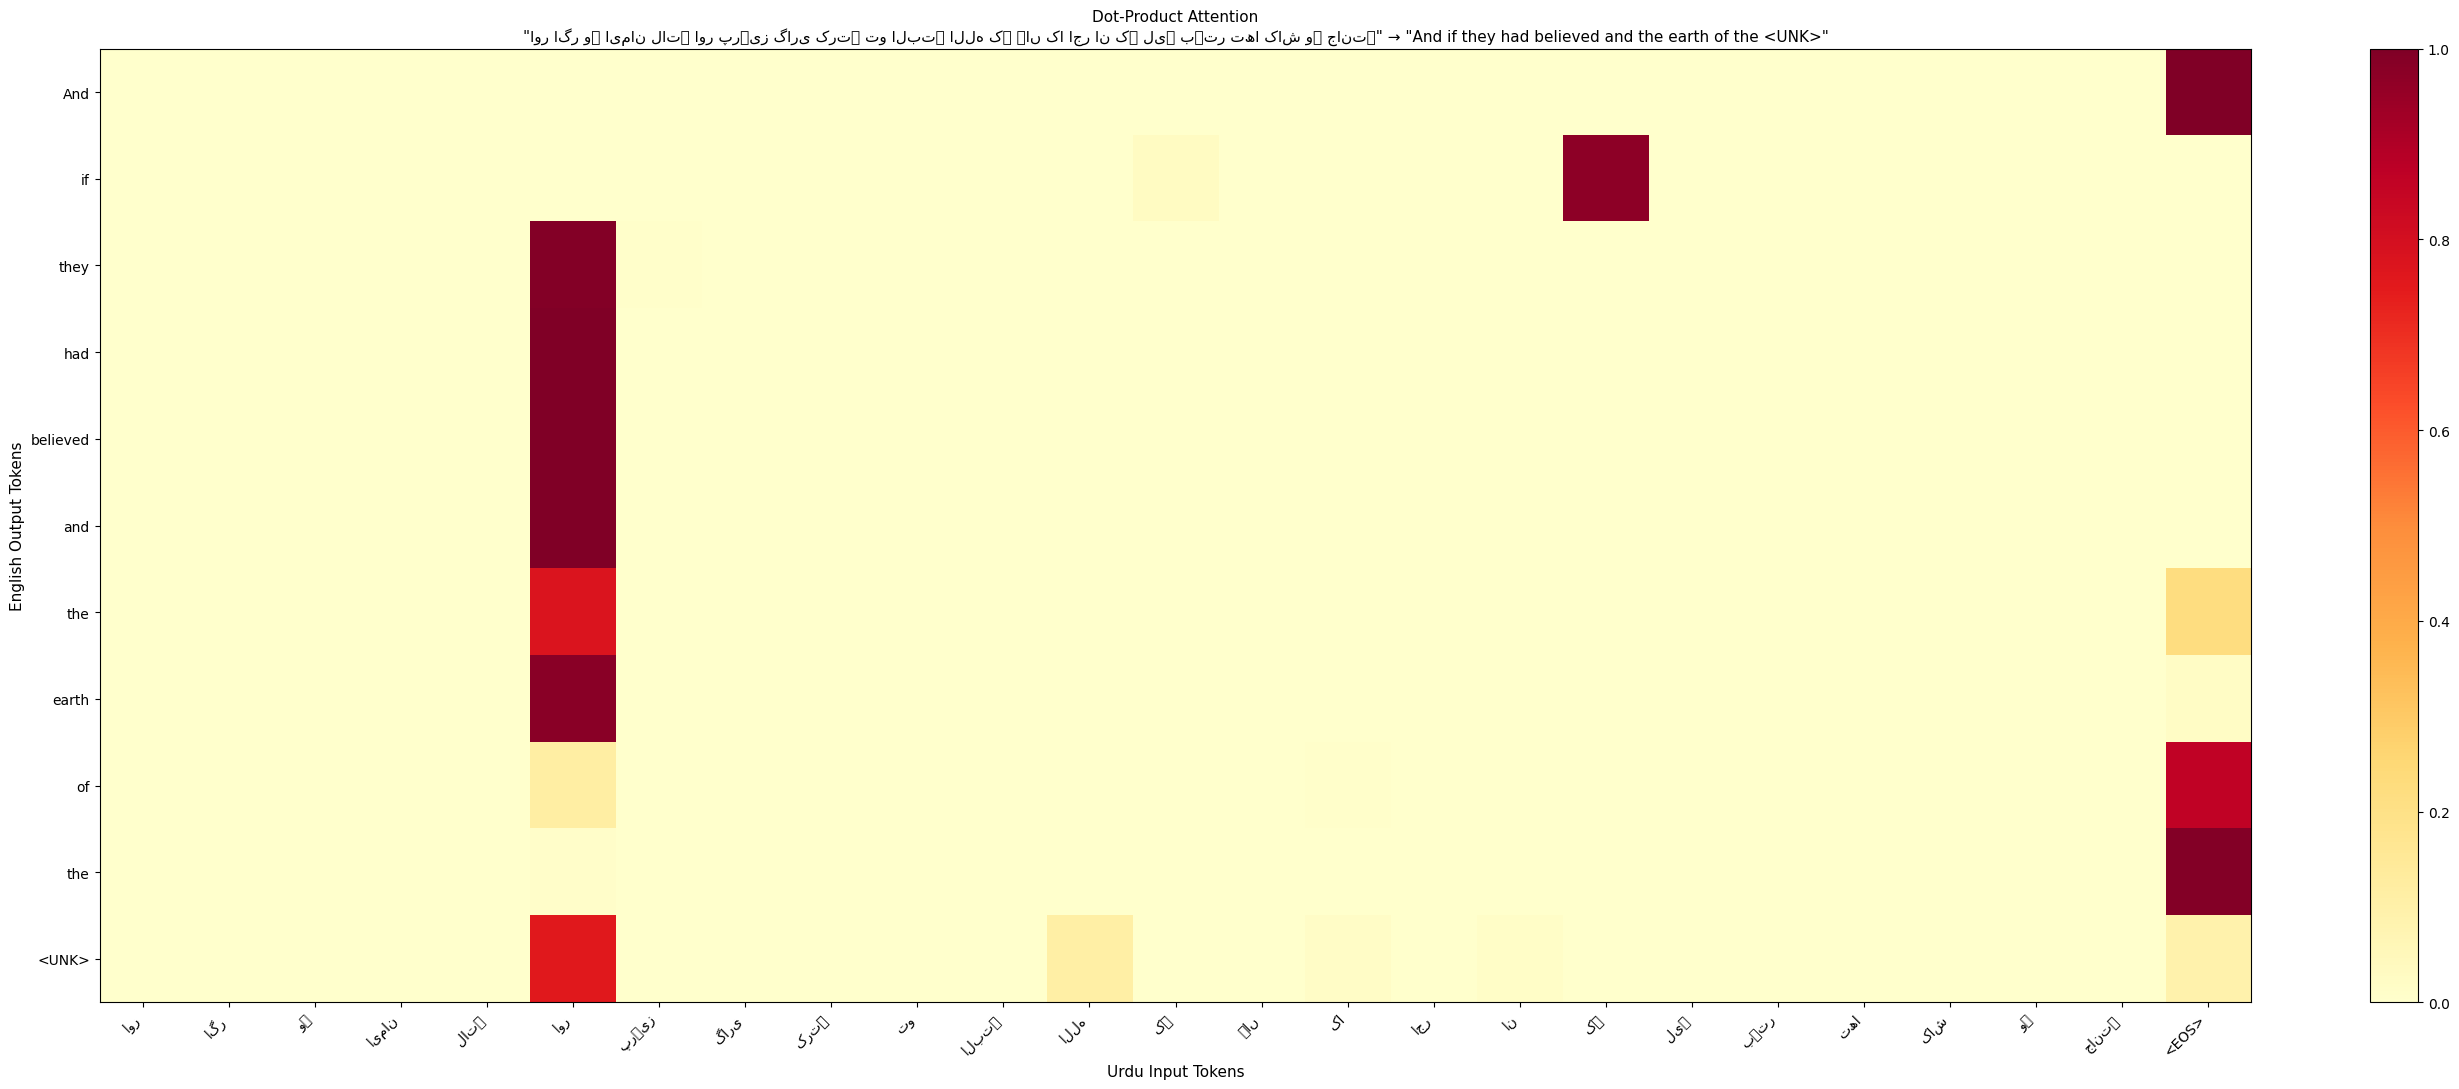

Translation: And if they had believed and the earth of the <UNK>


C:\Users\Mani\AppData\Local\Temp\ipykernel_17464\3419337391.py:23: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Mani\AppData\Local\Temp\ipykernel_17464\3419337391.py:23: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
C:\Users\Mani\AppData\Local\Temp\ipykernel_17464\3419337391.py:23: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Mani\AppData\Local\Temp\ipykernel_17464\3419337391.py:24: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.savefig(f'attn_{title.replace(" ","_").lower()}.png', dpi=120, bbox_inches='tight')
C:\Users\Mani\AppData\Local\Temp\ipykernel_17464\3419337391.py:24: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig(f'attn_{title.replace(" ","_").lower()}.png', dpi=120, bbox_inches='tight')
C:\Users\Mani\AppData\L

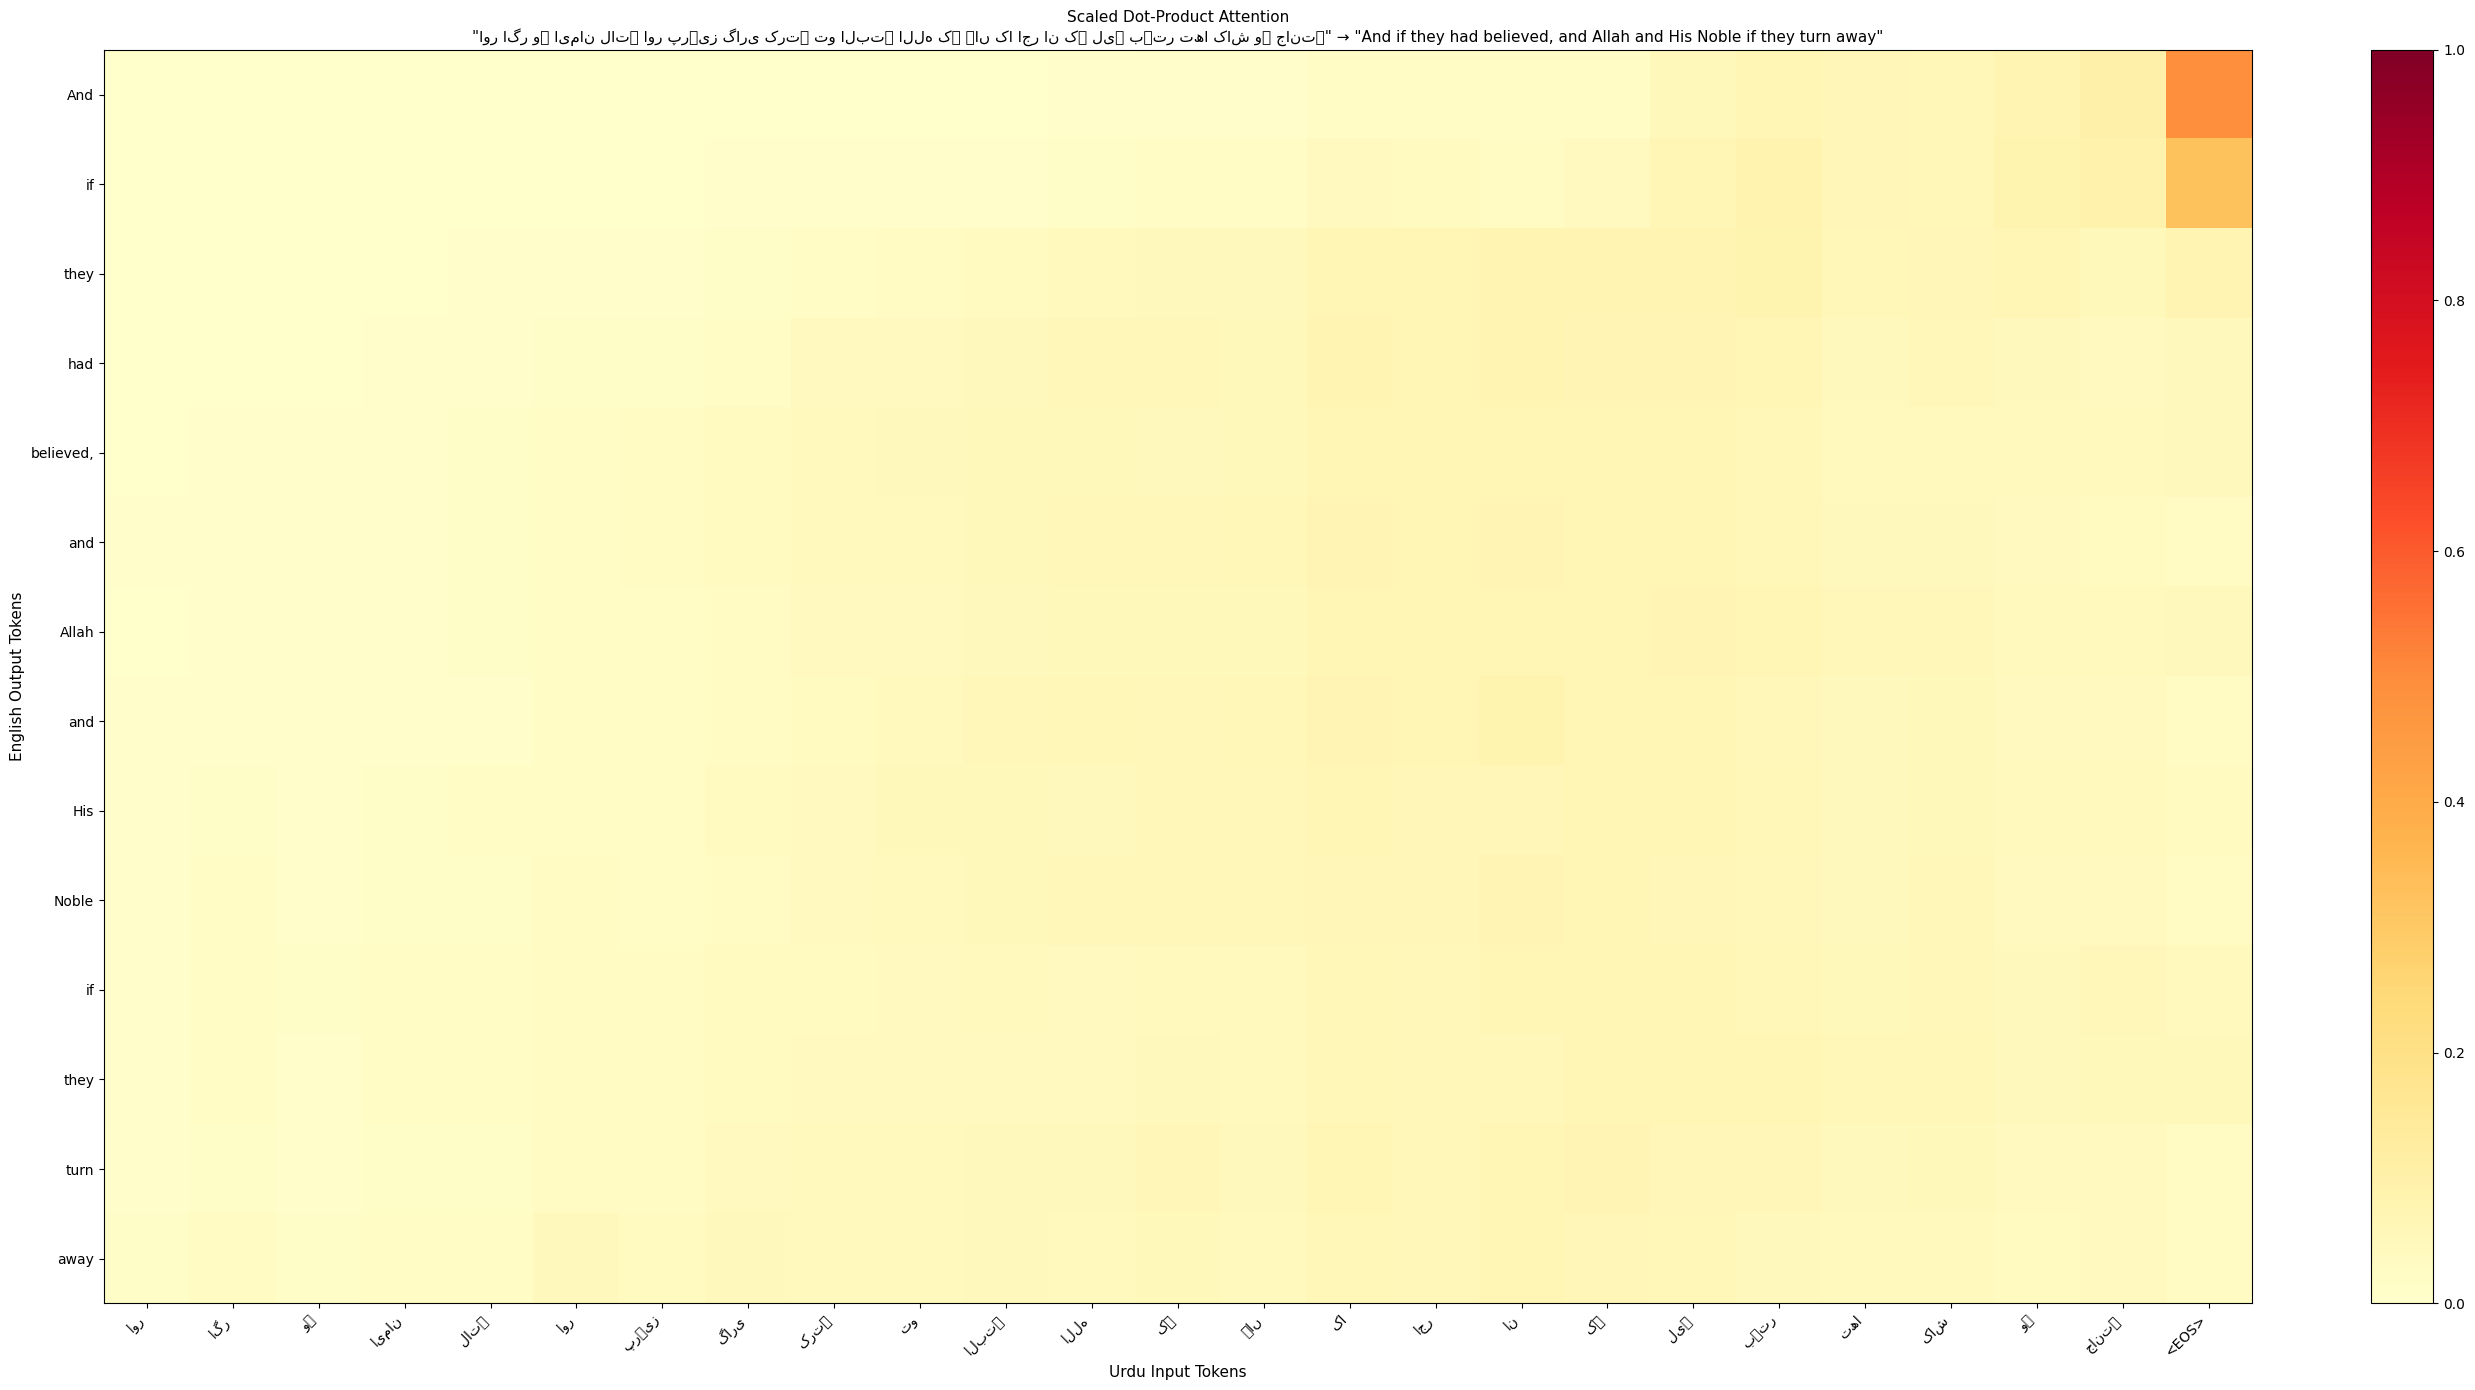

Translation: And if they had believed, and Allah and His Noble if they turn away


C:\Users\Mani\AppData\Local\Temp\ipykernel_17464\3419337391.py:23: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Mani\AppData\Local\Temp\ipykernel_17464\3419337391.py:23: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
C:\Users\Mani\AppData\Local\Temp\ipykernel_17464\3419337391.py:23: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Mani\AppData\Local\Temp\ipykernel_17464\3419337391.py:24: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.savefig(f'attn_{title.replace(" ","_").lower()}.png', dpi=120, bbox_inches='tight')
C:\Users\Mani\AppData\Local\Temp\ipykernel_17464\3419337391.py:24: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig(f'attn_{title.replace(" ","_").lower()}.png', dpi=120, bbox_inches='tight')
C:\Users\Mani\AppData\L

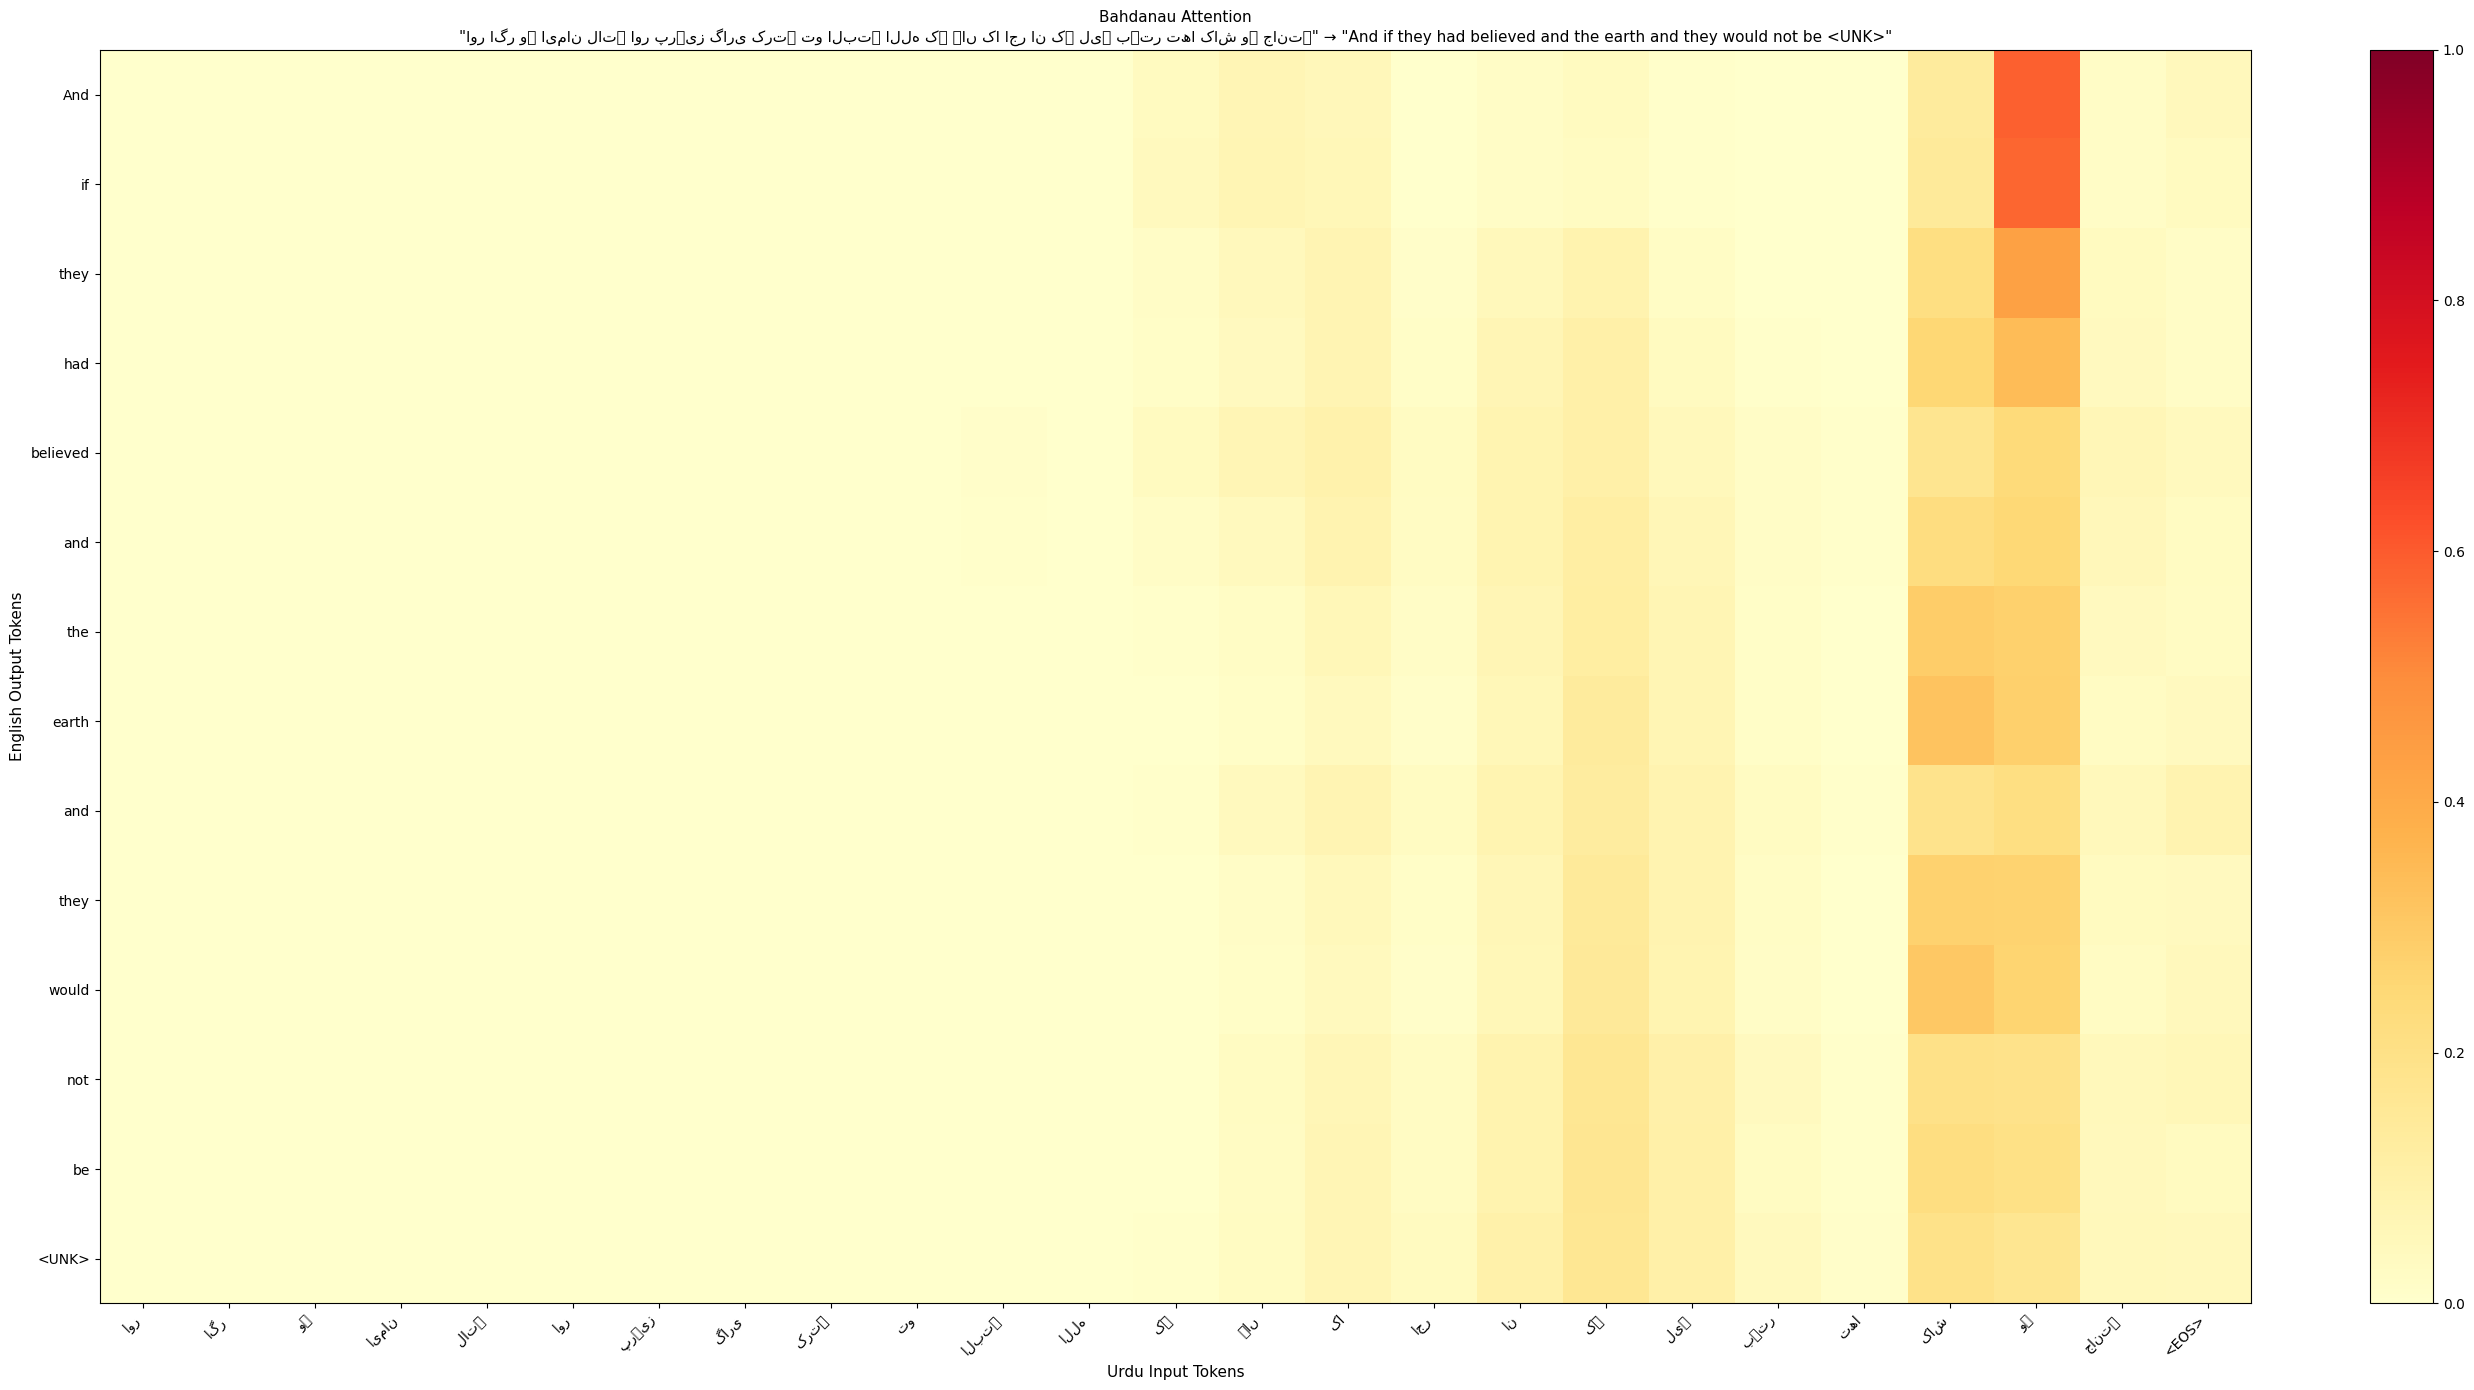

Translation: And if they had believed and the earth and they would not be <UNK>


In [77]:
# ✅ PROVIDED — Attention heatmap
def plot_attention(src_sentence, encoder, decoder, title='Attention Heatmap'):
    translation, attn_weights = translate(encoder, decoder, src_sentence, use_attn=True)
    if not attn_weights:
        print("No attention weights (is this an attention model?)"); return

    src_tokens = src_sentence.split() + ['<EOS>']
    tgt_tokens = translation.split()
    attn_matrix = np.array(attn_weights)   # (tgt_len, src_len)
    if attn_matrix.ndim == 1:
        attn_matrix = attn_matrix[np.newaxis, :]
    # Trim to actual lengths
    attn_matrix = attn_matrix[:len(tgt_tokens), :len(src_tokens)]

    fig, ax = plt.subplots(figsize=(max(6, len(src_tokens)), max(4, len(tgt_tokens))))
    im = ax.imshow(attn_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(src_tokens))); ax.set_xticklabels(src_tokens, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(len(tgt_tokens))); ax.set_yticklabels(tgt_tokens, fontsize=10)
    ax.set_xlabel('Urdu Input Tokens', fontsize=11)
    ax.set_ylabel('English Output Tokens', fontsize=11)
    ax.set_title(f'{title}\n"{src_sentence}" → "{translation}"', fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.savefig(f'attn_{title.replace(" ","_").lower()}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Translation: {translation}")

# Plot for all three attention models
example = test_sentences[0]
plot_attention(example, enc_dot,    dec_dot,    title='Dot-Product Attention')
plot_attention(example, enc_scaled, dec_scaled, title='Scaled Dot-Product Attention')
plot_attention(example, enc_bah,    dec_bah,    title='Bahdanau Attention')

### ✏️ Student Observation — Attention Heatmaps

*Look at the three heatmaps and answer:*

1. Do the attention patterns look similar across all three score functions?
2. Can you spot a word alignment (e.g., a Urdu word attended to its English translation)?
3. Are there any rows that are "diffuse" (spread equally)? What does that mean?
4. Compare Dot vs Scaled-Dot heatmaps. Is the Scaled-Dot version sharper or smoother?

**Your answers here:**

```
1. 
2. 
3. 
4. 
```

---
## Section 13 — BLEU Score Evaluation

> **BLEU** (Bilingual Evaluation Understudy) measures n-gram overlap
> between predicted and reference translations. Range: 0–100.
> Higher is better. State-of-the-art NMT: ~30–40 BLEU on standard benchmarks.

In [78]:
# ✅ PROVIDED
def compute_bleu(encoder, decoder, pairs_subset, use_attn=False):
    hypotheses, references = [], []
    for src_s, tgt_s in pairs_subset:
        pred, _ = translate(encoder, decoder, src_s, use_attn=use_attn)
        hypotheses.append(pred)
        references.append([tgt_s])
    bleu = sacrebleu.corpus_bleu(hypotheses, list(map(list, zip(*references))))
    return bleu.score

eval_pairs = pairs[split:split+200]
print("Computing BLEU scores (this may take ~30s)...")
bleu_base   = compute_bleu(enc_base,   dec_base,   eval_pairs, use_attn=False)
bleu_dot    = compute_bleu(enc_dot,    dec_dot,    eval_pairs, use_attn=True)
bleu_scaled = compute_bleu(enc_scaled, dec_scaled, eval_pairs, use_attn=True)
bleu_bah    = compute_bleu(enc_bah,    dec_bah,    eval_pairs, use_attn=True)

print("\n" + "=" * 45)
print(f"{'Model':<30} {'BLEU':>8}")
print("-" * 45)
print(f"{'LSTM (no attention)':<30} {bleu_base:>8.2f}")
print(f"{'LSTM + Dot Attention':<30} {bleu_dot:>8.2f}")
print(f"{'LSTM + Scaled Dot':<30} {bleu_scaled:>8.2f}")
print(f"{'LSTM + Bahdanau':<30} {bleu_bah:>8.2f}")
print("=" * 45)
best = max([(bleu_base,'No Attn'),(bleu_dot,'Dot'),(bleu_scaled,'Scaled Dot'),(bleu_bah,'Bahdanau')], key=lambda x: x[0])
print(f"\nBest model: {best[1]} with BLEU = {best[0]:.2f}")

Computing BLEU scores (this may take ~30s)...

Model                              BLEU
---------------------------------------------
LSTM (no attention)                0.37
LSTM + Dot Attention               1.31
LSTM + Scaled Dot                  0.78
LSTM + Bahdanau                    1.31

Best model: Bahdanau with BLEU = 1.31


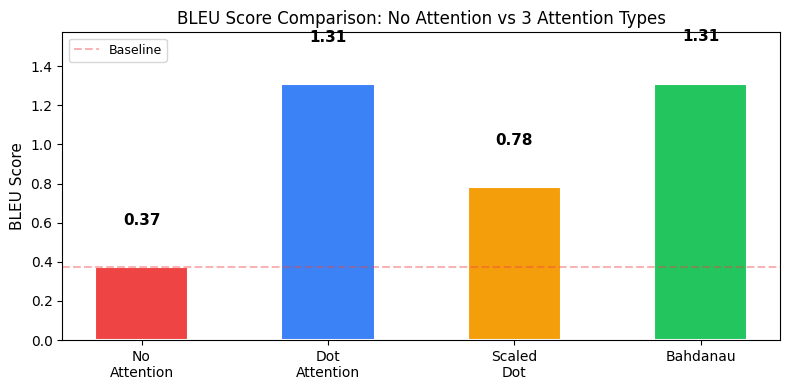

In [79]:
# ✅ PROVIDED — Bar chart of BLEU scores
fig, ax = plt.subplots(figsize=(8, 4))
models = ['No\nAttention', 'Dot\nAttention', 'Scaled\nDot', 'Bahdanau']
scores = [bleu_base, bleu_dot, bleu_scaled, bleu_bah]
colors = ['#ef4444', '#3b82f6', '#f59e0b', '#22c55e']
bars = ax.bar(models, scores, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{score:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('BLEU Score', fontsize=11)
ax.set_title('BLEU Score Comparison: No Attention vs 3 Attention Types', fontsize=12)
ax.set_ylim(0, max(scores) * 1.2)
ax.axhline(y=bleu_base, color='#ef4444', linestyle='--', alpha=0.4, label='Baseline')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('bleu_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 14 — Bonus: Attention Entropy Analysis

> **Attention entropy** measures how *spread out* the attention distribution is:
> ```
> H(α) = - Σᵢ αᵢ log αᵢ
> ```
> Low entropy → sharp, focused attention (model is certain)
> High entropy → diffuse attention (model is uncertain)
>
> Compare the entropy profiles of your three attention types.

In [80]:
# ✅ PROVIDED
def avg_entropy(encoder, decoder, sentences, n=50):
    entropies = []
    for s in sentences[:n]:
        _, attn = translate(encoder, decoder, s, use_attn=True)
        for a in attn:
            a = np.array(a).flatten() + 1e-9
            a = a / a.sum()
            entropies.append(-np.sum(a * np.log(a)))
    return np.mean(entropies)

test_srcs = [p[0] for p in pairs[split:]]
print("Computing attention entropy...")
e_dot    = avg_entropy(enc_dot,    dec_dot,    test_srcs)
e_scaled = avg_entropy(enc_scaled, dec_scaled, test_srcs)
e_bah    = avg_entropy(enc_bah,    dec_bah,    test_srcs)

print(f"\nAverage Attention Entropy:")
print(f"  Dot-product    : {e_dot:.4f}")
print(f"  Scaled dot     : {e_scaled:.4f}")
print(f"  Bahdanau       : {e_bah:.4f}")
print("\n(Lower entropy = sharper attention = more focused word alignments)")

Computing attention entropy...

Average Attention Entropy:
  Dot-product    : 0.4212
  Scaled dot     : 3.2120
  Bahdanau       : 1.4413

(Lower entropy = sharper attention = more focused word alignments)


### ✏️ Student Observation — Entropy & Final Summary

Answer these final questions based on ALL your results:

1. Which attention type produces the sharpest (lowest entropy) alignment? Why?
2. Why does scaled dot-product prevent softmax saturation?
3. In terms of BLEU score, was attention worth the extra complexity?
4. Which model would you choose to deploy? Justify (consider BLEU, speed, params).
5. What is the key difference between the **bottleneck** in the baseline and the **dynamic context** in attention models?

**Your answers here:**

```
1. 
2. 
3. 
4. 
5. 
```

---
**Well done! You have now implemented and compared:**
- LSTM Encoder-Decoder (baseline — no attention)
- Cross-Attention with 3 score functions: Dot · Scaled-Dot · Bahdanau
- Attention heatmap visualisation
- BLEU evaluation & entropy analysis

**Next lecture:** Transformers — remove the LSTM entirely and use only self-attention + positional encodings.

In [81]:
class SingleHeadAttention(nn.Module):
    """
    Single-Head Attention — Q, K, V projections ke saath.

    ScaledDotAttention se farq:
    - Pehle W_q, W_k, W_v se project karo (seekhe hue transformations)
    - Phir scaled dot-product attention lagao
    - Zyada flexible: Q aur K ki dimensionality hidden_dim se alag ho sakti hai

    Args:
        hidden_dim : encoder/decoder hidden size
        d_k        : query/key size (default = hidden_dim)
    """
    def __init__(self, hidden_dim, d_k=None):
        super().__init__()
        self.d_k = d_k if d_k is not None else hidden_dim

        # W_q: decoder state ko Query mein transform karo
        self.W_q = nn.Linear(hidden_dim, self.d_k, bias=False)
        # W_k: encoder states ko Keys mein transform karo
        self.W_k = nn.Linear(hidden_dim, self.d_k, bias=False)
        # W_v: encoder states ko Values mein transform karo (output size = hidden_dim)
        self.W_v = nn.Linear(hidden_dim, hidden_dim, bias=False)

    def forward(self, enc_outputs, decoder_h):
        """
        enc_outputs : (batch, src_len, hidden_dim)
        decoder_h   : (batch, 1, hidden_dim)
        Returns: context (batch,1,hidden_dim), attn_weights (batch,1,src_len)
        """
        # Step 1: Project
        Q = self.W_q(decoder_h)     # (batch, 1, d_k)
        K = self.W_k(enc_outputs)   # (batch, src_len, d_k)
        V = self.W_v(enc_outputs)   # (batch, src_len, hidden_dim)

        # Step 2: Scaled dot-product scores
        scores = torch.bmm(Q, K.transpose(1, 2))   # (batch, 1, src_len)
        scores = scores / math.sqrt(self.d_k)

        # Step 3: Softmax → attention weights
        attn_weights = F.softmax(scores, dim=-1)    # (batch, 1, src_len)

        # Step 4: Weighted sum of Values → dynamic context
        context = torch.bmm(attn_weights, V)        # (batch, 1, hidden_dim)

        return context, attn_weights


# Quick test
test_enc = torch.randn(2, 5, 256)
test_dec = torch.randn(2, 1, 256)
sha = SingleHeadAttention(hidden_dim=256)
ctx, w = sha(test_enc, test_dec)
print(f'SingleHeadAttention — context: {ctx.shape}, weights: {w.shape}')
print(f'Weights sum to 1? {w.sum(dim=-1)}')


SingleHeadAttention — context: torch.Size([2, 1, 256]), weights: torch.Size([2, 1, 5])
Weights sum to 1? tensor([[1.],
        [1.]], grad_fn=<SumBackward1>)


In [82]:
class MultiHeadAttention(nn.Module):
    """
    Multi-Head Cross-Attention.

    Socho: 4 students ne alag alag Urdu sentence padha, sab ne milke jawab diya.
    Har student (head) alag cheez par focus karta hai.

    Implementation trick: alag alag W matrices banane ki jagah ek badi matrix banao,
    phir reshape se heads mein split karo. Zyada efficient hai GPU par.

    Args:
        hidden_dim : model ka hidden size (hidden_dim % num_heads == 0 hona chahiye)
        num_heads  : parallel heads ki tadaad
    """
    def __init__(self, hidden_dim, num_heads=4):
        super().__init__()
        assert hidden_dim % num_heads == 0, (
            f'hidden_dim ({hidden_dim}) must be divisible by num_heads ({num_heads})'
        )
        self.hidden_dim = hidden_dim
        self.num_heads  = num_heads
        self.d_k        = hidden_dim // num_heads  # har head ka size

        # Ek badi projection matrix — internally sary heads handle karta hai
        self.W_q = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W_k = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W_v = nn.Linear(hidden_dim, hidden_dim, bias=False)
        # Final output projection — sary heads ko combine karta hai
        self.W_o = nn.Linear(hidden_dim, hidden_dim, bias=False)

    def split_heads(self, x, batch_size):
        """
        (batch, seq_len, hidden_dim) → (batch, num_heads, seq_len, d_k)

        Kyun? Badi projection matrix ko num_heads choti slices mein todna hai.
        Phir har slice ek head ka kaam karti hai.
        """
        # (batch, seq, hidden) → (batch, seq, num_heads, d_k)
        x = x.view(batch_size, -1, self.num_heads, self.d_k)
        # → (batch, num_heads, seq, d_k)  [heads ko batch dim ke paas lao]
        return x.permute(0, 2, 1, 3)

    def forward(self, enc_outputs, decoder_h):
        """
        enc_outputs : (batch, src_len, hidden_dim)
        decoder_h   : (batch, 1, hidden_dim)
        Returns:
            context      : (batch, 1, hidden_dim)
            attn_weights : (batch, num_heads, 1, src_len)  — visualization ke liye
        """
        batch_size = enc_outputs.size(0)

        # Step 1: Project (sary heads ek saath)
        Q = self.W_q(decoder_h)    # (batch, 1, hidden_dim)
        K = self.W_k(enc_outputs)  # (batch, src_len, hidden_dim)
        V = self.W_v(enc_outputs)  # (batch, src_len, hidden_dim)

        # Step 2: num_heads slices mein split karo
        Q = self.split_heads(Q, batch_size)  # (batch, num_heads, 1, d_k)
        K = self.split_heads(K, batch_size)  # (batch, num_heads, src_len, d_k)
        V = self.split_heads(V, batch_size)  # (batch, num_heads, src_len, d_k)

        # Step 3: Har head ke liye scaled dot-product
        # (batch, num_heads, 1, d_k) × (batch, num_heads, d_k, src_len)
        scores = torch.matmul(Q, K.transpose(-2, -1))  # (batch, num_heads, 1, src_len)
        scores = scores / math.sqrt(self.d_k)
        attn_weights = F.softmax(scores, dim=-1)

        # Step 4: Weighted sum
        head_out = torch.matmul(attn_weights, V)  # (batch, num_heads, 1, d_k)

        # Step 5: Concat sary heads
        # (batch, num_heads, 1, d_k) → (batch, 1, num_heads, d_k) → (batch, 1, hidden_dim)
        head_out = head_out.permute(0, 2, 1, 3).contiguous()
        context_cat = head_out.view(batch_size, 1, self.hidden_dim)

        # Step 6: W_o — heads ka combination seekhta hai
        context = self.W_o(context_cat)  # (batch, 1, hidden_dim)

        return context, attn_weights


# Test
mha = MultiHeadAttention(hidden_dim=256, num_heads=4)
ctx_mha, w_mha = mha(test_enc, test_dec)
print(f'MultiHeadAttention  — context: {ctx_mha.shape}')
print(f'Weights per head    : {w_mha.shape}')  # (batch, num_heads, 1, src_len)
print(f'Each head sums to 1 : {w_mha.sum(dim=-1).squeeze()}')


MultiHeadAttention  — context: torch.Size([2, 1, 256])
Weights per head    : torch.Size([2, 4, 1, 5])
Each head sums to 1 : tensor([[1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000]], grad_fn=<SqueezeBackward0>)


In [83]:
enc_sha = LSTMEncoder(len(src_vocab), EMBED_DIM, HIDDEN_DIM, DROPOUT).to(DEVICE)
dec_sha = LSTMDecoderWithAttn(
    len(tgt_vocab), EMBED_DIM, HIDDEN_DIM,
    SingleHeadAttention(HIDDEN_DIM),
    DROPOUT
).to(DEVICE)

enc_mha = LSTMEncoder(len(src_vocab), EMBED_DIM, HIDDEN_DIM, DROPOUT).to(DEVICE)
dec_mha = LSTMDecoderWithAttn(
    len(tgt_vocab), EMBED_DIM, HIDDEN_DIM,
    MultiHeadAttention(HIDDEN_DIM, num_heads=4),
    DROPOUT
).to(DEVICE)

print(f'Decoder (SingleHead)   : {count_params(dec_sha):,}')
print(f'Decoder (MultiHead-4)  : {count_params(dec_mha):,}')
print(f'Extra params MHA vs SHA: {count_params(dec_mha) - count_params(dec_sha):,}')
print('(W_o ki wajah se MHA mein thore zyada params hain)')


Decoder (SingleHead)   : 3,439,169
Decoder (MultiHead-4)  : 3,504,705
Extra params MHA vs SHA: 65,536
(W_o ki wajah se MHA mein thore zyada params hain)


In [84]:
print('=' * 55)
print('MODEL C1: LSTM + Single-Head Attention (with W_q/W_k/W_v)')
print('=' * 55)
losses_sha = train_model(enc_sha, dec_sha, use_attn=True, n_epochs=N_EPOCHS)


MODEL C1: LSTM + Single-Head Attention (with W_q/W_k/W_v)
Epoch  1 | Train Loss: 7.0022 | Val Loss: 5.8505 | PPL: 347.42
Epoch  2 | Train Loss: 5.6563 | Val Loss: 5.6882 | PPL: 295.36
Epoch  3 | Train Loss: 5.4562 | Val Loss: 5.5817 | PPL: 265.53
Epoch  4 | Train Loss: 5.3109 | Val Loss: 5.4916 | PPL: 242.65
Epoch  5 | Train Loss: 5.1699 | Val Loss: 5.4043 | PPL: 222.36
Epoch  6 | Train Loss: 5.0227 | Val Loss: 5.3135 | PPL: 203.05
Epoch  7 | Train Loss: 4.8691 | Val Loss: 5.2512 | PPL: 190.79
Epoch  8 | Train Loss: 4.7171 | Val Loss: 5.1767 | PPL: 177.09
Epoch  9 | Train Loss: 4.5536 | Val Loss: 5.1147 | PPL: 166.44
Epoch 10 | Train Loss: 4.3915 | Val Loss: 5.0577 | PPL: 157.23
Epoch 11 | Train Loss: 4.2349 | Val Loss: 5.0522 | PPL: 156.36
Epoch 12 | Train Loss: 4.0816 | Val Loss: 5.0458 | PPL: 155.37
Epoch 13 | Train Loss: 3.9182 | Val Loss: 5.0339 | PPL: 153.53
Epoch 14 | Train Loss: 3.7659 | Val Loss: 5.0287 | PPL: 152.73
Epoch 15 | Train Loss: 3.6076 | Val Loss: 5.0276 | PPL: 152.

In [85]:
print('=' * 55)
print('MODEL C2: LSTM + Multi-Head Attention (4 heads)')
print('=' * 55)
losses_mha = train_model(enc_mha, dec_mha, use_attn=True, n_epochs=N_EPOCHS)


MODEL C2: LSTM + Multi-Head Attention (4 heads)
Epoch  1 | Train Loss: 6.8236 | Val Loss: 5.8334 | PPL: 341.53
Epoch  2 | Train Loss: 5.6458 | Val Loss: 5.6960 | PPL: 297.68
Epoch  3 | Train Loss: 5.4513 | Val Loss: 5.5883 | PPL: 267.27
Epoch  4 | Train Loss: 5.2929 | Val Loss: 5.4951 | PPL: 243.49
Epoch  5 | Train Loss: 5.1358 | Val Loss: 5.3764 | PPL: 216.25
Epoch  6 | Train Loss: 4.9735 | Val Loss: 5.2991 | PPL: 200.16


KeyboardInterrupt: 

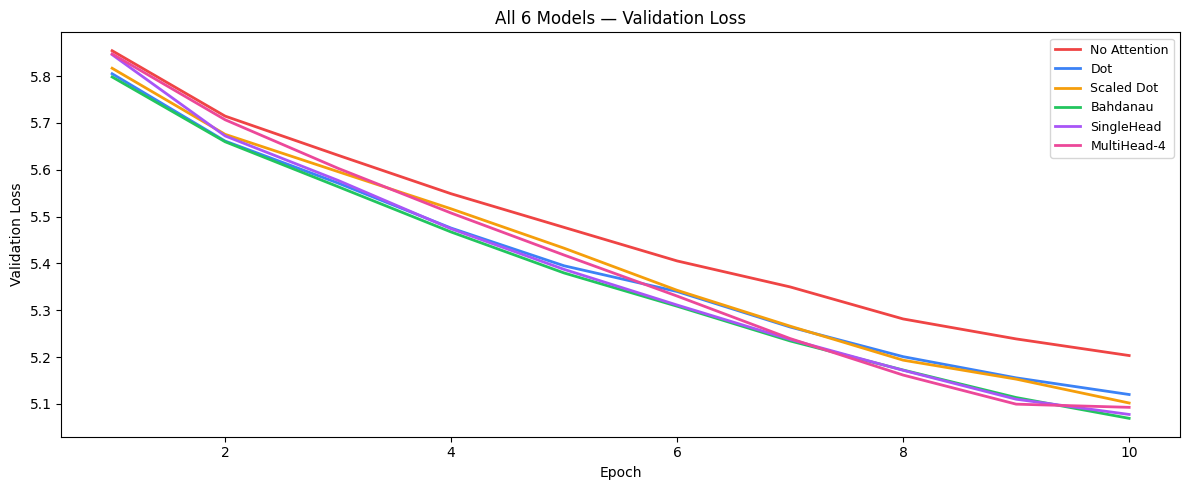

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
all_labels  = ['No Attention','Dot','Scaled Dot','Bahdanau','SingleHead','MultiHead-4']
all_colors  = ['#ef4444','#3b82f6','#f59e0b','#22c55e','#a855f7','#ec4899']
all_results = [losses_base, losses_dot, losses_scaled, losses_bah, losses_sha, losses_mha]
epochs = range(1, N_EPOCHS + 1)
for (_, vl), lbl, col in zip(all_results, all_labels, all_colors):
    ax.plot(epochs, vl, label=lbl, linewidth=2, color=col)
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Loss')
ax.set_title('All 6 Models — Validation Loss')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('all_models_val_loss.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
print('Computing BLEU for new models...')
bleu_sha = compute_bleu(enc_sha, dec_sha, eval_pairs, use_attn=True)
bleu_mha = compute_bleu(enc_mha, dec_mha, eval_pairs, use_attn=True)

print('\n' + '=' * 50)
print(f'{"Model":<32} {"BLEU":>8}')
print('-' * 50)
rows = [
    ('LSTM (no attention)',       bleu_base),
    ('LSTM + Dot',                bleu_dot),
    ('LSTM + Scaled Dot',         bleu_scaled),
    ('LSTM + Bahdanau',           bleu_bah),
    ('LSTM + SingleHead (proj)',  bleu_sha),
    ('LSTM + MultiHead-4',        bleu_mha),
]
for name, score in rows:
    print(f'{name:<32} {score:>8.2f}')
print('=' * 50)
best = max(rows, key=lambda x: x[1])
print(f'Best model: {best[0]}  BLEU={best[1]:.2f}')


Computing BLEU for new models...

Model                                BLEU
--------------------------------------------------
LSTM (no attention)                  0.08
LSTM + Dot                           0.49
LSTM + Scaled Dot                    0.29
LSTM + Bahdanau                      0.49
LSTM + SingleHead (proj)             0.43
LSTM + MultiHead-4                   0.68
Best model: LSTM + MultiHead-4  BLEU=0.68


C:\Users\Mani\AppData\Local\Temp\ipykernel_17464\2133764600.py:51: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Mani\AppData\Local\Temp\ipykernel_17464\2133764600.py:51: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
C:\Users\Mani\AppData\Local\Temp\ipykernel_17464\2133764600.py:51: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Mani\AppData\Local\Temp\ipykernel_17464\2133764600.py:52: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.savefig('multihead_heatmap.png', dpi=120, bbox_inches='tight')
C:\Users\Mani\AppData\Local\Temp\ipykernel_17464\2133764600.py:52: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig('multihead_heatmap.png', dpi=120, bbox_inches='tight')
C:\Users\Mani\AppData\Local\Temp\ipykernel_17464\2133764600.py:52

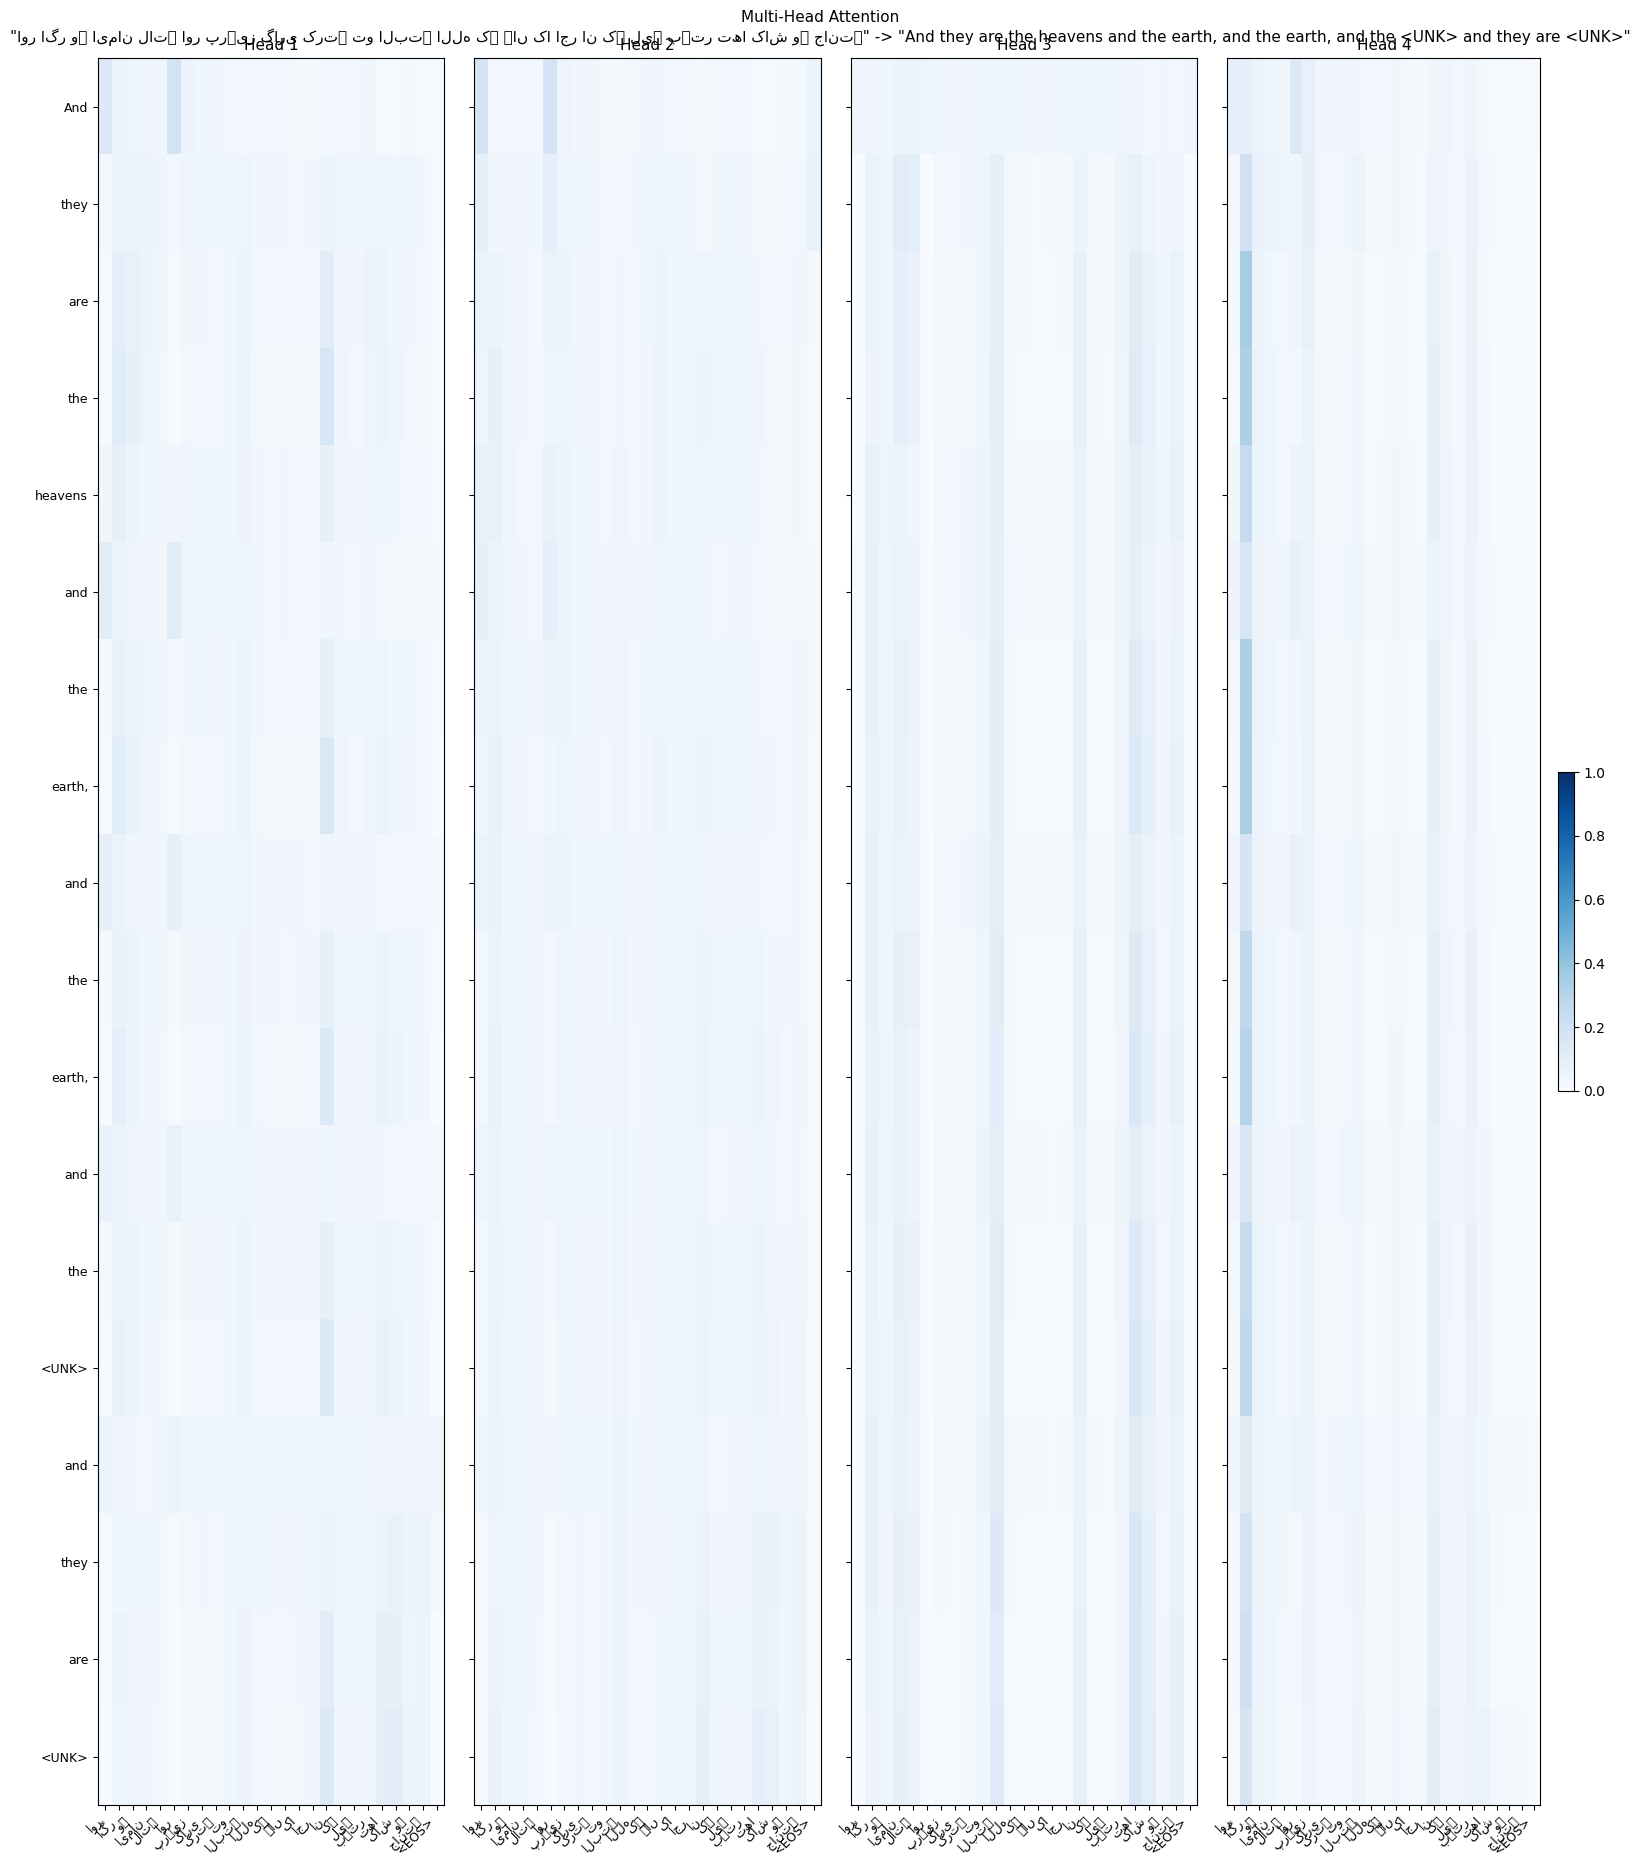

Translation: And they are the heavens and the earth, and the earth, and the <UNK> and they are <UNK>


In [ ]:
@torch.no_grad()
def translate_mha(encoder, decoder, sentence, max_len=30):
    """Multi-head ke liye translate — sary heads ke weights return karta hai."""
    encoder.eval(); decoder.eval()
    tokens = torch.tensor(encode(sentence, src_vocab) + [EOS]).unsqueeze(0).to(DEVICE)
    enc_out, enc_hidden = encoder(tokens)
    dec_token = torch.tensor([[SOS]]).to(DEVICE)
    result, all_head_attns = [], []
    hidden = enc_hidden
    for _ in range(max_len):
        q = hidden[0].permute(1, 0, 2)
        ctx, attn_w = decoder.score_fn(enc_out, q)
        # attn_w: (batch, num_heads, 1, src_len) → squeeze batch → (num_heads, src_len)
        all_head_attns.append(attn_w.squeeze(0).squeeze(1).cpu().numpy())
        emb = decoder.dropout(decoder.embedding(dec_token))
        lstm_in = torch.cat([emb, ctx], dim=-1)
        out, hidden = decoder.lstm(lstm_in, hidden)
        out_ctx = torch.cat([out, ctx], dim=-1)
        logit = decoder.fc(out_ctx)
        pred = logit.argmax(-1).item()
        if pred == EOS: break
        result.append(tgt_idx2word.get(pred, '<UNK>'))
        dec_token = torch.tensor([[pred]]).to(DEVICE)
    return ' '.join(result), all_head_attns


def plot_multihead_attention(src_sentence, encoder, decoder, num_heads=4):
    translation, all_head_attns = translate_mha(encoder, decoder, src_sentence)
    if not all_head_attns:
        print('No attention weights'); return
    src_tokens  = src_sentence.split() + ['<EOS>']
    tgt_tokens  = translation.split()
    tgt_len, src_len = len(tgt_tokens), len(src_tokens)
    # (tgt_len, num_heads, src_len)
    attn_arr = np.array(all_head_attns)[:tgt_len, :, :src_len]

    fig, axes = plt.subplots(1, num_heads, figsize=(4 * num_heads, max(4, tgt_len + 1)))
    if num_heads == 1: axes = [axes]
    for h, ax in enumerate(axes):
        im = ax.imshow(attn_arr[:, h, :], cmap='Blues', aspect='auto', vmin=0, vmax=1)
        ax.set_xticks(range(src_len))
        ax.set_xticklabels(src_tokens, rotation=45, ha='right', fontsize=9)
        ax.set_yticks(range(tgt_len))
        ax.set_yticklabels(tgt_tokens if h == 0 else [], fontsize=9)
        ax.set_title(f'Head {h+1}', fontsize=11)
    fig.suptitle(
        f'Multi-Head Attention\n"{src_sentence}" -> "{translation}"',
        fontsize=11
    )
    plt.colorbar(im, ax=axes[-1], fraction=0.046)
    plt.tight_layout()
    plt.savefig('multihead_heatmap.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Translation: {translation}')


plot_multihead_attention(test_sentences[0], enc_mha, dec_mha, num_heads=4)
